# Plan1d K=40 per-patient full regularization-path analysis

This notebook is the per-patient companion to the full-range pooled analysis.

Focus of this version:

- use `per_patient_cv` runs from `plan1c_supervised_latent_k40_full_all`
- select the **most parsimonious non-zero** model for sparse penalties (`l1`, `elasticnet`)
- characterize **patient heterogeneity** across DR methods, penalties, and downsampling settings
- project selected latent coefficients back to genes for signature similarity analyses
- optionally run Hallmark GSEA on the selected per-patient signatures

Important interpretation note:

- CV metrics in the grid tables are computed on held-out validation folds for each patient-specific run
- coefficient sparsity comes from the full-data refit at the same hyperparameter setting
- for sparse penalties, this notebook excludes all-zero endpoints before choosing the strongest regularization

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional
import math
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sns.set_context("notebook")
sns.set_style("whitegrid")

RESULT_ROOT = Path(
    "/home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all"
)
OUTPUT_DIR = Path(
    "/home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP_DIR = RESULT_ROOT.parents[2]
K_FIXED = 40
SELECTION_MODE = "most_parsimonious_nonzero"
SPARSE_ZERO_ELIGIBLE_PENALTIES = {"l1", "elasticnet"}

print(f"RESULT_ROOT: {RESULT_ROOT}")
print(f"EXP_DIR:     {EXP_DIR}")
print(f"OUTPUT_DIR:  {OUTPUT_DIR}")
print(f"SELECTION_MODE: {SELECTION_MODE}")

RESULT_ROOT: /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886/models/classification/plan1c_supervised_latent_k40_full_all
EXP_DIR:     /home/minhang/mds_project/sc_classification/experiments/20260211_212806_plan0_k_sweep_60_none_hvg_c06f4886
OUTPUT_DIR:  /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319
SELECTION_MODE: most_parsimonious_nonzero


In [2]:
def discover_available_runs(result_root: Path, cv_mode: str = "per_patient_cv") -> pd.DataFrame:
    rows = []
    if cv_mode != "per_patient_cv":
        raise ValueError("This notebook is for per_patient_cv runs.")

    pattern = "*/*/*_coefficient_path_*.csv"
    for path in sorted((result_root / cv_mode).glob(pattern)):
        method = path.parent.parent.name
        downsampling = path.parent.name
        name = path.stem
        patient, suffix = name.split("_coefficient_path_", maxsplit=1)
        penalty = suffix
        rows.append(
            {
                "cv_mode": cv_mode,
                "patient": patient,
                "method": method,
                "downsampling": downsampling,
                "penalty": penalty,
                "coef_path": path,
                "metrics_path": path.with_name(path.name.replace("_coefficient_path_", "_grid_metrics_")),
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"No runs found under {result_root / cv_mode}")
    return df


def load_pair(row: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    coef_df = pd.read_csv(row["coef_path"])
    metrics_df = pd.read_csv(row["metrics_path"])

    numeric_cols = [
        "alpha",
        "C",
        "coef",
        "abs_coef",
        "is_nonzero",
        "l1_ratio",
        "auc_mean",
        "auc_std",
        "ap_mean",
        "ap_std",
        "acc_mean",
        "acc_std",
        "mal_recall_mean",
        "mal_recall_std",
        "nonzero_coef_count_full_refit",
    ]
    for col in numeric_cols:
        if col in coef_df.columns:
            coef_df[col] = pd.to_numeric(coef_df[col], errors="coerce")
        if col in metrics_df.columns:
            metrics_df[col] = pd.to_numeric(metrics_df[col], errors="coerce")

    return coef_df, metrics_df


def pretty_downsampling(value: str) -> str:
    return "no-downsampling" if str(value).lower() == "none" else str(value)


def get_class_counts_from_oof(row: pd.Series) -> dict | None:
    oof_path = row["metrics_path"].with_name(f"{row['patient']}_oof_predictions_best_{row['penalty']}.csv")
    if not oof_path.exists():
        return None
    oof_df = pd.read_csv(oof_path, usecols=["y"])
    vc = oof_df["y"].value_counts(dropna=False)
    return {"malignant": int(vc.get(1, 0)), "healthy": int(vc.get(0, 0))}


def _errorbar_or_line(ax, x, y, yerr, label, marker):
    if yerr is not None:
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt=f"{marker}-",
            markersize=4,
            capsize=3,
            capthick=1.0,
            elinewidth=1.0,
            lw=1.6,
            label=label,
        )
    else:
        ax.plot(x, y, marker=marker, markersize=4, lw=1.6, label=label)


def plot_metric_panel(ax, metrics_sub: pd.DataFrame, title: str, class_counts: dict | None = None):
    m = metrics_sub.sort_values("alpha")
    x = m["alpha"].values

    auc_std = m["auc_std"] if "auc_std" in m.columns else None
    _errorbar_or_line(ax, x, m["auc_mean"], auc_std, "AUC", "o")

    if "ap_mean" in m.columns:
        ap_std = m["ap_std"] if "ap_std" in m.columns else None
        _errorbar_or_line(ax, x, m["ap_mean"], ap_std, "AP", "s")

    if "acc_mean" in m.columns:
        acc_std = m["acc_std"] if "acc_std" in m.columns else None
        _errorbar_or_line(ax, x, m["acc_mean"], acc_std, "Accuracy", "^")

    if "mal_recall_mean" in m.columns:
        mr_std = m["mal_recall_std"] if "mal_recall_std" in m.columns else None
        _errorbar_or_line(ax, x, m["mal_recall_mean"], mr_std, "Malignant recall", "D")

    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("metric")
    ax.set_title(title)

    if "nonzero_coef_count_full_refit" in m.columns:
        ax2 = ax.twinx()
        ax2.plot(
            x,
            m["nonzero_coef_count_full_refit"],
            color="black",
            linestyle="--",
            lw=1.4,
            label="#nonzero",
        )
        ax2.set_ylabel("#nonzero coef")

    if class_counts is not None:
        ann = f"n_mal={class_counts.get('malignant', np.nan)}, n_healthy={class_counts.get('healthy', np.nan)}"
        ax.text(0.01, 0.01, ann, transform=ax.transAxes, fontsize=9, va="bottom", ha="left")

    ax.grid(True, alpha=0.25)


def plot_hyperparam_heatmaps(metrics_df: pd.DataFrame, title_prefix: str):
    d = metrics_df.copy()
    if "l1_ratio" not in d.columns or d["l1_ratio"].isna().all():
        return None

    piv_auc = d.pivot_table(index="l1_ratio", columns="alpha", values="auc_mean", aggfunc="mean")
    piv_ap = d.pivot_table(index="l1_ratio", columns="alpha", values="ap_mean", aggfunc="mean")
    piv_nz = d.pivot_table(index="l1_ratio", columns="alpha", values="nonzero_coef_count_full_refit", aggfunc="mean")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    sns.heatmap(piv_auc, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"{title_prefix} | AUC")
    sns.heatmap(piv_ap, cmap="magma", ax=axes[1])
    axes[1].set_title(f"{title_prefix} | AP")
    sns.heatmap(piv_nz, cmap="crest", ax=axes[2])
    axes[2].set_title(f"{title_prefix} | #nonzero")

    for ax in axes:
        ax.set_xlabel("alpha")
        ax.set_ylabel("l1_ratio")

    return fig


per_patient_index = discover_available_runs(RESULT_ROOT, cv_mode="per_patient_cv")
print(f"Discovered per-patient runs: {len(per_patient_index)}")
print(f"Unique patients: {per_patient_index['patient'].nunique()}")
display(
    per_patient_index[["patient", "method", "downsampling", "penalty"]]
    .drop_duplicates()
    .sort_values(["patient", "method", "downsampling", "penalty"])
    .reset_index(drop=True)
)

plot_dir = OUTPUT_DIR / "per_patient_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

saved = []
for _, row in per_patient_index.sort_values(["patient", "method", "downsampling", "penalty"]).iterrows():
    _, metrics_df = load_pair(row)
    class_counts = get_class_counts_from_oof(row)

    title = (
        f"per_patient_cv | patient={row.patient} | {row.method} | "
        f"{pretty_downsampling(row.downsampling)} | {row.penalty}"
    )
    base_name = f"per_patient__{row.patient}__{row.method}__{row.downsampling}__{row.penalty}"

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.5))
    plot_metric_panel(ax, metrics_df, title=title, class_counts=class_counts)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="best", frameon=True)
    fig.tight_layout()
    out = plot_dir / f"{base_name}.png"
    fig.savefig(out, dpi=160)
    plt.close(fig)
    saved.append(out)

    hm = plot_hyperparam_heatmaps(metrics_df, title)
    if hm is not None:
        out_hm = plot_dir / f"{base_name}__heatmaps.png"
        hm.savefig(out_hm, dpi=160)
        plt.close(hm)
        saved.append(out_hm)

print(f"Saved {len(saved)} plot files to {plot_dir}")

Discovered per-patient runs: 270
Unique patients: 9


,patient,method,downsampling,penalty
0,P01,cnmf,none,elasticnet
1,P01,cnmf,none,l1
2,P01,cnmf,none,l2
3,P01,cnmf,random,elasticnet
4,P01,cnmf,random,l1
...,...,...,...,...
265,P13,pca,none,l1
266,P13,pca,none,l2
267,P13,pca,random,elasticnet
268,P13,pca,random,l1


Saved 360 plot files to /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319/per_patient_plots


,patient,method,downsampling_display,penalty,selected_alpha,selected_l1_ratio,mal_recall_mean,auc_mean,ap_mean,nonzero_coef_count_full_refit,strongest_alpha_has_any_nonzero
0,P01,cnmf,no-downsampling,elasticnet,3792.690191,0.2,0.480000,0.635617,0.008571,2.0,False
1,P01,cnmf,no-downsampling,l1,428.133240,NaN,0.595556,0.883229,0.038326,2.0,False
2,P01,cnmf,no-downsampling,l2,100000.000000,NaN,0.551111,0.842895,0.024830,40.0,True
3,P01,cnmf,random,elasticnet,143.844989,0.2,0.291111,0.729940,0.221735,2.0,False
4,P01,cnmf,random,l1,16.237767,NaN,0.606667,0.872227,0.398875,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...
265,P13,pca,no-downsampling,l1,11288.378917,NaN,0.500000,0.636998,0.001892,1.0,False
266,P13,pca,no-downsampling,l2,100000.000000,NaN,0.750000,0.990589,0.371720,40.0,True
267,P13,pca,random,elasticnet,428.133240,0.2,0.250000,0.661711,0.249251,3.0,False
268,P13,pca,random,l1,143.844989,NaN,0.550000,0.635658,0.124663,1.0,False


,method,downsampling,penalty,n_patients,mean_alpha,sd_alpha,mean_nonzero,sd_nonzero,mean_mal_recall,sd_mal_recall,mean_auc,sd_auc,strongest_alpha_zero_endpoint_count
0,cnmf,none,elasticnet,9,1272.051649,1030.184341,1.222222,0.440959,0.618808,0.204913,0.761963,0.166776,9
1,cnmf,none,l1,9,269.944344,189.854998,1.777778,0.833333,0.571358,0.213450,0.818339,0.129927,9
2,cnmf,none,l2,9,100000.000000,0.000000,40.000000,0.000000,0.668745,0.239384,0.899686,0.063634,0
3,cnmf,random,elasticnet,9,339.419638,387.539234,1.555556,0.726483,0.517951,0.193241,0.837937,0.100137,9
4,cnmf,random,l1,9,85.681670,134.974645,1.333333,0.500000,0.685090,0.240889,0.738751,0.179271,9
5,cnmf,random,l2,9,100000.000000,0.000000,40.000000,0.000000,0.889808,0.116795,0.888811,0.072985,0
6,fa,none,elasticnet,9,5451.781364,4511.236557,3.444444,2.351123,0.753245,0.133673,0.742554,0.196066,9
7,fa,none,l1,9,866.624404,491.188427,2.777778,2.438123,0.777974,0.173173,0.759566,0.197035,9
8,fa,none,l2,9,100000.000000,0.000000,40.000000,0.000000,0.682432,0.148120,0.933813,0.052984,0
9,fa,random,elasticnet,9,1843.086432,3575.944661,3.333333,2.598076,0.713872,0.194348,0.754215,0.188760,9


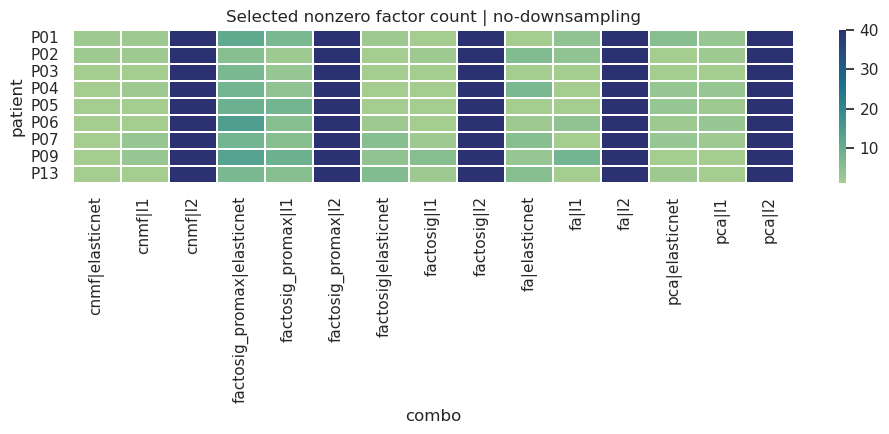

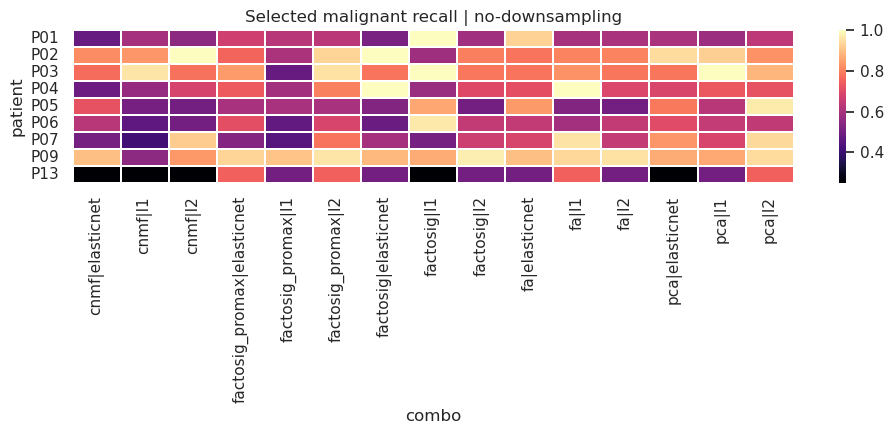

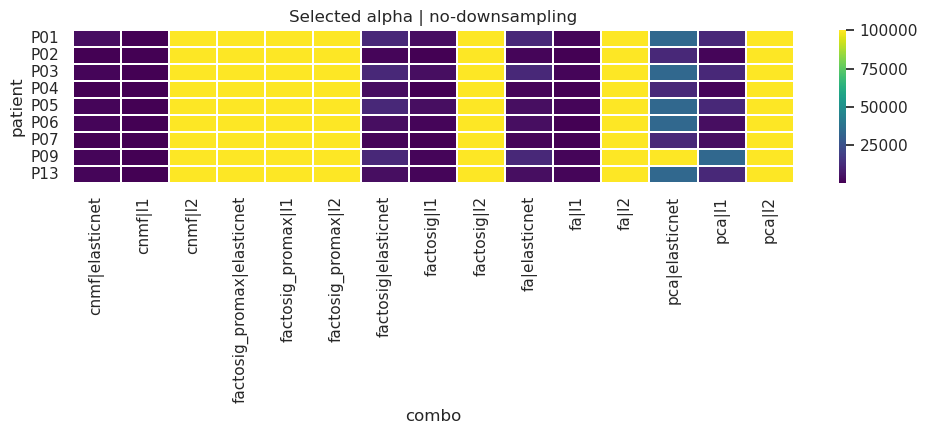

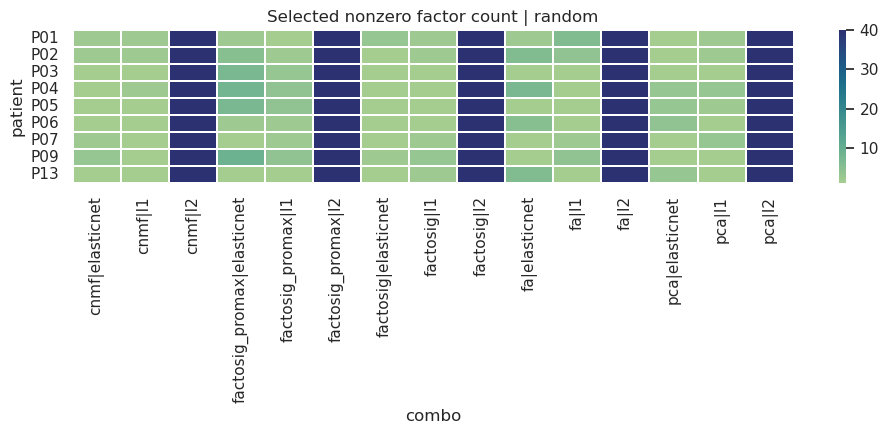

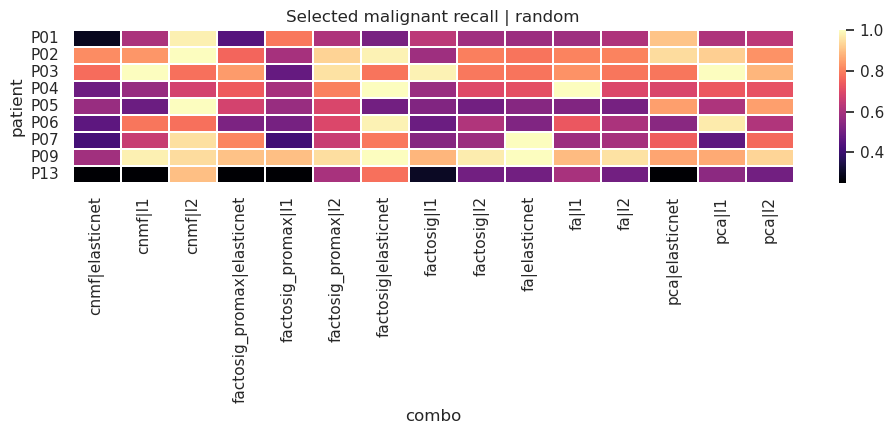

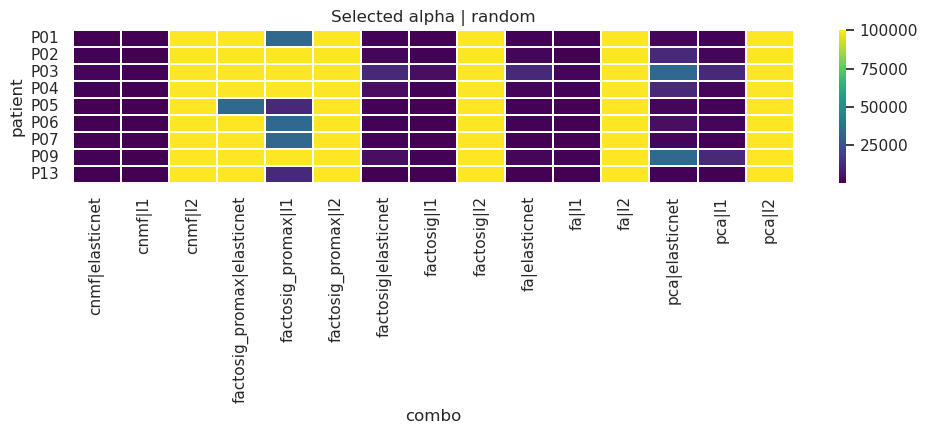

,patient,method,penalty,selected_alpha_none,selected_alpha_random,delta_mal_recall_mean,delta_auc_mean,delta_ap_mean,delta_nonzero_coef_count_full_refit
0,P01,cnmf,elasticnet,3792.690191,143.844989,-0.188889,0.094322,0.213164,0.0
1,P01,cnmf,l1,428.133240,16.237767,0.011111,-0.011002,0.360549,0.0
2,P01,cnmf,l2,100000.000000,100000.000000,0.426667,-0.004251,0.309200,0.0
3,P01,fa,elasticnet,11288.378917,428.133240,-0.348889,0.121122,0.206144,1.0
4,P01,fa,l1,1274.274986,48.329302,-0.015556,-0.024777,0.263184,2.0
...,...,...,...,...,...,...,...,...,...
130,P13,factosig_promax,l1,100000.000000,11288.378917,-0.250000,-0.280792,0.126432,-4.0
131,P13,factosig_promax,l2,100000.000000,100000.000000,-0.150000,-0.160488,0.200615,0.0
132,P13,pca,elasticnet,33598.182863,428.133240,0.000000,-0.024993,0.243786,1.0
133,P13,pca,l1,11288.378917,143.844989,0.050000,-0.001340,0.122771,0.0


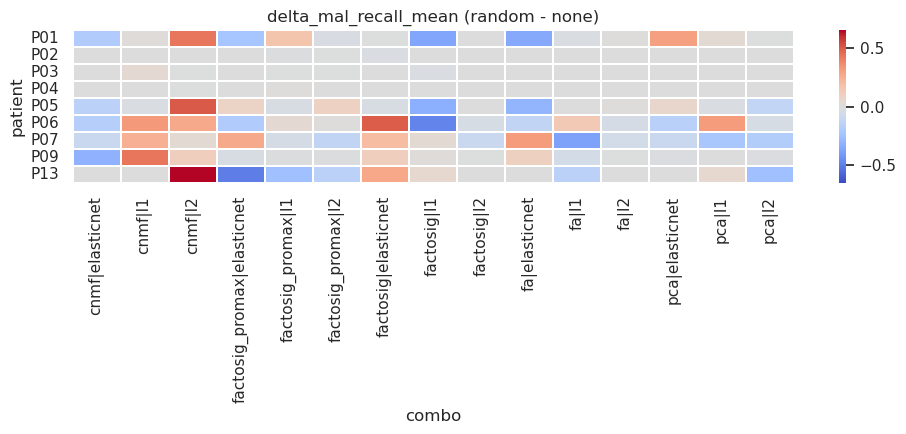

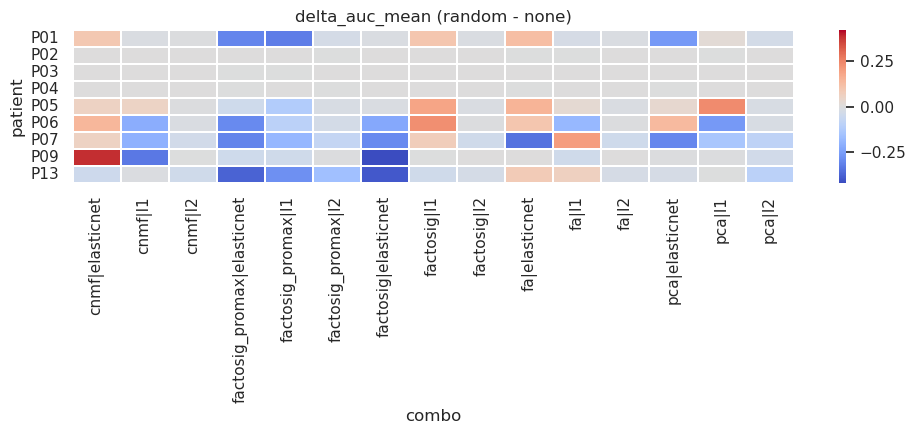

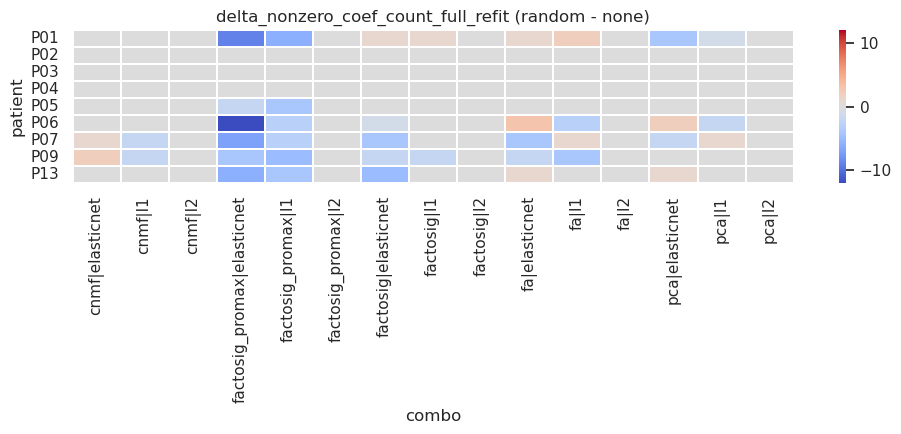

Saved per-patient selection, heterogeneity, and downsampling summaries to OUTPUT_DIR


In [3]:
def _prepare_selection_frame(metrics_df: pd.DataFrame) -> pd.DataFrame:
    d = metrics_df.copy()
    d["alpha"] = pd.to_numeric(d["alpha"], errors="coerce")
    d["C"] = pd.to_numeric(d.get("C"), errors="coerce")
    d["l1_ratio"] = pd.to_numeric(d.get("l1_ratio"), errors="coerce")
    d["mal_recall_mean"] = pd.to_numeric(d.get("mal_recall_mean"), errors="coerce").fillna(-np.inf)
    d["auc_mean"] = pd.to_numeric(d.get("auc_mean"), errors="coerce").fillna(-np.inf)
    d["ap_mean"] = pd.to_numeric(d.get("ap_mean"), errors="coerce").fillna(-np.inf)
    d["acc_mean"] = pd.to_numeric(d.get("acc_mean"), errors="coerce").fillna(-np.inf)
    d["nonzero_coef_count_full_refit"] = (
        pd.to_numeric(d.get("nonzero_coef_count_full_refit"), errors="coerce").fillna(np.inf)
    )
    return d


def _restrict_sparse_candidates_to_nonzero(
    d: pd.DataFrame,
    penalty: str,
    require_nonzero_for_sparse_penalties: bool = True,
) -> pd.DataFrame:
    if not require_nonzero_for_sparse_penalties or penalty not in SPARSE_ZERO_ELIGIBLE_PENALTIES:
        return d

    nz = d[d["nonzero_coef_count_full_refit"] > 0].copy()
    if nz.empty:
        raise ValueError(
            f"No non-zero candidate models remain for penalty={penalty}. "
            "Check whether the full path is entirely collapsed to zero."
        )
    return nz


def select_model_row(
    metrics_df: pd.DataFrame,
    penalty: str,
    selection_mode: str = "most_parsimonious_nonzero",
    recall_delta: float = 0.01,
    auc_delta: float = 0.005,
    ap_delta: float = 0.01,
    require_nonzero_for_sparse_penalties: bool = True,
) -> pd.Series:
    d = _prepare_selection_frame(metrics_df)
    d = _restrict_sparse_candidates_to_nonzero(
        d,
        penalty=penalty,
        require_nonzero_for_sparse_penalties=require_nonzero_for_sparse_penalties,
    )

    if selection_mode == "most_parsimonious_nonzero":
        max_alpha = d["alpha"].max()
        d = d[np.isclose(d["alpha"], max_alpha, atol=1e-12)].copy()
        d = d.sort_values(
            ["mal_recall_mean", "auc_mean", "ap_mean", "nonzero_coef_count_full_refit"],
            ascending=[False, False, False, True],
        )
        return d.iloc[0]

    if selection_mode == "recall_first_nonzero":
        best_recall = d["mal_recall_mean"].max()
        d1 = d[d["mal_recall_mean"] >= (best_recall - recall_delta)]
        best_auc = d1["auc_mean"].max()
        d2 = d1[d1["auc_mean"] >= (best_auc - auc_delta)]
        best_ap = d2["ap_mean"].max()
        d3 = d2[d2["ap_mean"] >= (best_ap - ap_delta)]
        d3 = d3.sort_values(["nonzero_coef_count_full_refit", "alpha"], ascending=[True, False])
        return d3.iloc[0]

    raise ValueError(f"Unsupported selection_mode: {selection_mode}")


def build_per_patient_selection_table(index_df: pd.DataFrame, selection_mode: str) -> pd.DataFrame:
    rows = []
    for _, run_row in index_df.sort_values(["patient", "method", "downsampling", "penalty"]).iterrows():
        _, metrics_df = load_pair(run_row)
        chosen = select_model_row(metrics_df, penalty=run_row.penalty, selection_mode=selection_mode)
        class_counts = get_class_counts_from_oof(run_row) or {"malignant": np.nan, "healthy": np.nan}

        strongest_alpha = float(pd.to_numeric(metrics_df["alpha"], errors="coerce").max())
        strongest_rows = metrics_df[np.isclose(pd.to_numeric(metrics_df["alpha"], errors="coerce"), strongest_alpha, atol=1e-12)].copy()
        strongest_nz = pd.to_numeric(strongest_rows.get("nonzero_coef_count_full_refit"), errors="coerce")
        strongest_alpha_has_any_nonzero = bool((strongest_nz.fillna(0) > 0).any())

        rows.append(
            {
                "patient": run_row.patient,
                "method": run_row.method,
                "downsampling": run_row.downsampling,
                "downsampling_display": pretty_downsampling(run_row.downsampling),
                "penalty": run_row.penalty,
                "selection_mode": selection_mode,
                "selected_alpha": float(chosen["alpha"]),
                "selected_C": float(chosen["C"]),
                "selected_l1_ratio": float(chosen["l1_ratio"]) if pd.notna(chosen.get("l1_ratio", np.nan)) else np.nan,
                "auc_mean": float(chosen["auc_mean"]),
                "auc_std": float(chosen["auc_std"]) if "auc_std" in chosen else np.nan,
                "ap_mean": float(chosen["ap_mean"]),
                "ap_std": float(chosen["ap_std"]) if "ap_std" in chosen else np.nan,
                "acc_mean": float(chosen["acc_mean"]),
                "acc_std": float(chosen["acc_std"]) if "acc_std" in chosen else np.nan,
                "mal_recall_mean": float(chosen["mal_recall_mean"]),
                "mal_recall_std": float(chosen["mal_recall_std"]) if "mal_recall_std" in chosen else np.nan,
                "nonzero_coef_count_full_refit": float(chosen["nonzero_coef_count_full_refit"]),
                "strongest_alpha": strongest_alpha,
                "strongest_alpha_has_any_nonzero": strongest_alpha_has_any_nonzero,
                "malignant_cells": class_counts["malignant"],
                "healthy_cells": class_counts["healthy"],
                "coef_path": run_row.coef_path,
                "metrics_path": run_row.metrics_path,
            }
        )

    return pd.DataFrame(rows)


def build_downsampling_effect_report(selected_df: pd.DataFrame) -> pd.DataFrame:
    none_df = selected_df[selected_df["downsampling"] == "none"].copy()
    rand_df = selected_df[selected_df["downsampling"] == "random"].copy()

    cmp = none_df.merge(
        rand_df,
        on=["patient", "method", "penalty", "selection_mode"],
        suffixes=("_none", "_random"),
    )

    for metric in [
        "mal_recall_mean",
        "auc_mean",
        "ap_mean",
        "acc_mean",
        "nonzero_coef_count_full_refit",
    ]:
        cmp[f"delta_{metric}"] = cmp[f"{metric}_random"] - cmp[f"{metric}_none"]

    return cmp


def plot_patient_combo_heatmap(df: pd.DataFrame, value_col: str, downsampling: str, title: str, cmap: str = "viridis"):
    sub = df[df["downsampling"] == downsampling].copy()
    sub["combo"] = sub["method"].astype(str) + "|" + sub["penalty"].astype(str)
    mat = sub.pivot(index="patient", columns="combo", values=value_col)
    mat = mat.reindex(index=sorted(mat.index), columns=sorted(mat.columns))

    fig, ax = plt.subplots(figsize=(max(10, 0.6 * mat.shape[1]), max(4, 0.5 * mat.shape[0])))
    sns.heatmap(mat, cmap=cmap, linewidths=0.2, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()


def summarize_patient_heterogeneity(selected_df: pd.DataFrame) -> pd.DataFrame:
    return (
        selected_df.groupby(["method", "downsampling", "penalty"], observed=False)
        .agg(
            n_patients=("patient", "nunique"),
            mean_alpha=("selected_alpha", "mean"),
            sd_alpha=("selected_alpha", "std"),
            mean_nonzero=("nonzero_coef_count_full_refit", "mean"),
            sd_nonzero=("nonzero_coef_count_full_refit", "std"),
            mean_mal_recall=("mal_recall_mean", "mean"),
            sd_mal_recall=("mal_recall_mean", "std"),
            mean_auc=("auc_mean", "mean"),
            sd_auc=("auc_mean", "std"),
            strongest_alpha_zero_endpoint_count=("strongest_alpha_has_any_nonzero", lambda s: int((~pd.Series(s)).sum())),
        )
        .reset_index()
        .sort_values(["method", "downsampling", "penalty"])
    )


selected_pp = build_per_patient_selection_table(per_patient_index, selection_mode=SELECTION_MODE)
display(
    selected_pp[
        [
            "patient",
            "method",
            "downsampling_display",
            "penalty",
            "selected_alpha",
            "selected_l1_ratio",
            "mal_recall_mean",
            "auc_mean",
            "ap_mean",
            "nonzero_coef_count_full_refit",
            "strongest_alpha_has_any_nonzero",
        ]
    ]
    .sort_values(["patient", "method", "downsampling_display", "penalty"])
    .reset_index(drop=True)
)

heterogeneity_summary = summarize_patient_heterogeneity(selected_pp)
display(heterogeneity_summary)

for downsampling in ["none", "random"]:
    plot_patient_combo_heatmap(
        selected_pp,
        value_col="nonzero_coef_count_full_refit",
        downsampling=downsampling,
        title=f"Selected nonzero factor count | {pretty_downsampling(downsampling)}",
        cmap="crest",
    )
    plot_patient_combo_heatmap(
        selected_pp,
        value_col="mal_recall_mean",
        downsampling=downsampling,
        title=f"Selected malignant recall | {pretty_downsampling(downsampling)}",
        cmap="magma",
    )
    plot_patient_combo_heatmap(
        selected_pp,
        value_col="selected_alpha",
        downsampling=downsampling,
        title=f"Selected alpha | {pretty_downsampling(downsampling)}",
        cmap="viridis",
    )

cmp_pp = build_downsampling_effect_report(selected_pp)
display(
    cmp_pp[
        [
            "patient",
            "method",
            "penalty",
            "selected_alpha_none",
            "selected_alpha_random",
            "delta_mal_recall_mean",
            "delta_auc_mean",
            "delta_ap_mean",
            "delta_nonzero_coef_count_full_refit",
        ]
    ]
    .sort_values(["patient", "method", "penalty"])
    .reset_index(drop=True)
)

for metric in ["delta_mal_recall_mean", "delta_auc_mean", "delta_nonzero_coef_count_full_refit"]:
    tmp = cmp_pp.copy()
    tmp["combo"] = tmp["method"].astype(str) + "|" + tmp["penalty"].astype(str)
    mat = tmp.pivot(index="patient", columns="combo", values=metric).reindex(index=sorted(tmp["patient"].unique()))
    fig, ax = plt.subplots(figsize=(max(10, 0.6 * mat.shape[1]), max(4, 0.5 * mat.shape[0])))
    vmax = np.nanmax(np.abs(mat.values))
    vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1e-6
    sns.heatmap(mat, cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax, linewidths=0.2, linecolor="white", ax=ax)
    ax.set_title(f"{metric} (random - none)")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

selected_pp.to_csv(OUTPUT_DIR / f"per_patient_selected_models__{SELECTION_MODE}.csv", index=False)
heterogeneity_summary.to_csv(OUTPUT_DIR / f"per_patient_heterogeneity_summary__{SELECTION_MODE}.csv", index=False)
cmp_pp.to_csv(OUTPUT_DIR / f"per_patient_downsampling_effect__{SELECTION_MODE}.csv", index=False)
print("Saved per-patient selection, heterogeneity, and downsampling summaries to OUTPUT_DIR")

In [4]:
def load_df_npz(path: Path) -> pd.DataFrame:
    z = np.load(path, allow_pickle=True)
    return pd.DataFrame(z["data"], index=z["index"], columns=z["columns"])


def get_gene_names(exp_dir: Path) -> pd.Index:
    ad = sc.read_h5ad(exp_dir / "preprocessing" / "adata_processed.h5ad", backed="r")
    genes = ad.var_names.copy()
    del ad
    return genes


def load_gene_loadings(exp_dir: Path, method: str, k: int = 40) -> pd.DataFrame:
    genes = get_gene_names(exp_dir)

    if method in {"fa", "factosig"}:
        adk = sc.read_h5ad(exp_dir / "preprocessing" / f"adata_processed_with_plan0_dr_k{k}_seed1.h5ad", backed="r")
        key = "FA_loadings" if method == "fa" else "FACTOSIG_loadings"
        L = np.asarray(adk.varm[key])
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        out = pd.DataFrame(L, index=genes, columns=cols)
        del adk
        return out

    if method in {"pca", "factosig_promax"}:
        p = exp_dir / "analysis" / "plan0" / "stability" / method / f"k_{k}" / "replicates" / "seed_1" / "loadings.npy"
        L = np.load(p)
        cols = [f"{method}_{i+1}" for i in range(L.shape[1])]
        return pd.DataFrame(L, index=genes, columns=cols)

    if method == "cnmf":
        p = exp_dir / "models" / "cnmf_plan0" / "curated" / f"k_{k}" / "consensus" / f"plan0_cnmf.spectra.k_{k}.dt_0_5.consensus.df.npz"
        S = load_df_npz(p)
        L = S.T.copy()
        L.columns = L.columns.astype(str)
        return L

    raise ValueError(f"Unsupported method: {method}")


def coef_vector_at_selected_point(coef_df: pd.DataFrame, alpha: float, l1_ratio: float | None) -> pd.Series:
    c = coef_df.copy()
    c = c[np.isclose(c["alpha"], alpha, atol=1e-12)]

    if "l1_ratio" in c.columns:
        if pd.isna(l1_ratio):
            c = c[c["l1_ratio"].isna()]
        else:
            c = c[np.isclose(c["l1_ratio"], l1_ratio, atol=1e-12)]

    if c.empty:
        raise ValueError("No coefficient rows found for selected alpha/l1_ratio")

    w = c.groupby("feature", observed=False)["coef"].mean()
    w.index = w.index.astype(str)
    return w


def build_selected_signatures_per_patient(selected_df: pd.DataFrame, exp_dir: Path, k: int = 40) -> pd.DataFrame:
    method_loadings: dict[str, pd.DataFrame] = {}
    signatures = {}

    for _, r in selected_df.iterrows():
        method = r["method"]
        if method not in method_loadings:
            method_loadings[method] = load_gene_loadings(exp_dir, method, k=k)

        L = method_loadings[method].copy()
        L.columns = L.columns.astype(str)

        coef_df = pd.read_csv(r["coef_path"])
        w = coef_vector_at_selected_point(coef_df, alpha=r["selected_alpha"], l1_ratio=r["selected_l1_ratio"])
        w = w.reindex(L.columns).fillna(0.0)

        s = L.values @ w.values
        model_id = f"{r['patient']}|{method}|{r['downsampling']}|{r['penalty']}"
        signatures[model_id] = pd.Series(s, index=L.index)

    return pd.DataFrame(signatures)


def cosine_similarity_matrix(X: pd.DataFrame) -> pd.DataFrame:
    A = X.values
    denom = np.linalg.norm(A, axis=0, keepdims=True)
    denom[denom == 0] = 1.0
    A_norm = A / denom
    sim = A_norm.T @ A_norm
    return pd.DataFrame(sim, index=X.columns, columns=X.columns)


def jaccard_matrix(sets_by_name: dict[str, set]) -> pd.DataFrame:
    names = list(sets_by_name.keys())
    out = pd.DataFrame(index=names, columns=names, dtype=float)
    for a in names:
        for b in names:
            A, B = sets_by_name[a], sets_by_name[b]
            union_size = len(A | B)
            out.loc[a, b] = len(A & B) / union_size if union_size > 0 else np.nan
    return out


sig_df_pp = build_selected_signatures_per_patient(selected_pp, EXP_DIR, k=K_FIXED)
print("Signature matrix shape (genes x selected per-patient models):", sig_df_pp.shape)

sig_out = OUTPUT_DIR / "per_patient_signatures"
sig_out.mkdir(parents=True, exist_ok=True)
sig_df_pp.to_csv(sig_out / f"per_patient_selected_signatures__{SELECTION_MODE}.csv")

TOP_N = 200
pairwise_rows = []
for patient, sub in selected_pp.groupby("patient", observed=False):
    model_cols = [
        f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}"
        for _, r in sub.iterrows()
    ]
    model_cols = [c for c in model_cols if c in sig_df_pp.columns]
    if not model_cols:
        continue

    sig_sub = sig_df_pp[model_cols]
    cos_sim = cosine_similarity_matrix(sig_sub)
    pearson_sim = sig_sub.corr(method="pearson")

    pos_sets = {name: set(sig_sub[name].nlargest(TOP_N).index.astype(str)) for name in sig_sub.columns}
    neg_sets = {name: set(sig_sub[name].nsmallest(TOP_N).index.astype(str)) for name in sig_sub.columns}
    pos_j = jaccard_matrix(pos_sets)
    neg_j = jaccard_matrix(neg_sets)

    patient_dir = sig_out / str(patient)
    patient_dir.mkdir(parents=True, exist_ok=True)
    cos_sim.to_csv(patient_dir / "cosine_similarity.csv")
    pearson_sim.to_csv(patient_dir / "pearson_similarity.csv")
    pos_j.to_csv(patient_dir / f"top{TOP_N}_positive_gene_jaccard.csv")
    neg_j.to_csv(patient_dir / f"top{TOP_N}_negative_gene_jaccard.csv")

    fig, axes = plt.subplots(2, 2, figsize=(20, 16), constrained_layout=True)
    sns.heatmap(cos_sim, cmap="vlag", center=0, xticklabels=1, yticklabels=1, ax=axes[0, 0])
    axes[0, 0].set_title(f"{patient}: cosine similarity")
    sns.heatmap(pearson_sim, cmap="vlag", center=0, xticklabels=1, yticklabels=1, ax=axes[0, 1])
    axes[0, 1].set_title(f"{patient}: Pearson correlation")
    sns.heatmap(pos_j, cmap="YlGnBu", vmin=0, vmax=1, xticklabels=1, yticklabels=1, ax=axes[1, 0])
    axes[1, 0].set_title(f"{patient}: top+{TOP_N} Jaccard")
    sns.heatmap(neg_j, cmap="YlOrBr", vmin=0, vmax=1, xticklabels=1, yticklabels=1, ax=axes[1, 1])
    axes[1, 1].set_title(f"{patient}: top-{TOP_N} Jaccard")
    for ax in axes.ravel():
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
    fig.savefig(patient_dir / "similarity_and_jaccard_heatmaps.png", dpi=160)
    plt.close(fig)

for combo, sub in selected_pp.groupby(["method", "downsampling", "penalty"], observed=False):
    model_cols = [
        f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}"
        for _, r in sub.iterrows()
        if f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}" in sig_df_pp.columns
    ]
    if len(model_cols) < 2:
        continue

    sim = cosine_similarity_matrix(sig_df_pp[model_cols])
    vals = sim.values[np.triu_indices_from(sim.values, k=1)]
    pairwise_rows.append(
        {
            "method": combo[0],
            "downsampling": combo[1],
            "penalty": combo[2],
            "n_patients": len(model_cols),
            "mean_pairwise_cosine": float(np.nanmean(vals)),
            "sd_pairwise_cosine": float(np.nanstd(vals)),
        }
    )

cross_patient_signature_summary = pd.DataFrame(pairwise_rows).sort_values(["method", "downsampling", "penalty"])
display(cross_patient_signature_summary)
cross_patient_signature_summary.to_csv(
    sig_out / f"cross_patient_signature_similarity_summary__{SELECTION_MODE}.csv",
    index=False,
)
print("Saved per-patient signature outputs to:", sig_out)

Signature matrix shape (genes x selected per-patient models): (10000, 270)


,method,downsampling,penalty,n_patients,mean_pairwise_cosine,sd_pairwise_cosine
0,cnmf,none,elasticnet,9,0.554096,0.328636
1,cnmf,none,l1,9,0.668323,0.315334
2,cnmf,none,l2,9,0.369163,0.237649
3,cnmf,random,elasticnet,9,0.551667,0.300607
4,cnmf,random,l1,9,0.666962,0.320606
5,cnmf,random,l2,9,0.338587,0.255969
6,fa,none,elasticnet,9,0.136979,0.259780
7,fa,none,l1,9,0.036052,0.168048
8,fa,none,l2,9,0.365566,0.217146
9,fa,random,elasticnet,9,0.127837,0.240423


Saved per-patient signature outputs to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319/per_patient_signatures


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model_uid,rank,program_name,cosine_similarity
0,P01|cnmf|none|elasticnet,1,IFN-epsilon,-0.011199
1,P01|cnmf|none|elasticnet,2,IFN-lambda3,-0.032543
2,P01|cnmf|none|elasticnet,3,IFN-lambda2,-0.038166
3,P01|cnmf|none|elasticnet,4,TNF-alpha,-0.039021
4,P01|cnmf|none|elasticnet,5,IFN-beta,-0.061123
...,...,...,...,...
1345,P13|pca|random|l2,1,IFN-epsilon,0.110393
1346,P13|pca|random|l2,2,IFN-lambda1,0.082802
1347,P13|pca|random|l2,3,TNF-alpha,0.057415
1348,P13|pca|random|l2,4,IFN-lambda2,0.052466


,model_uid,rank,program_name,cosine_similarity
0,P01|cnmf|none|elasticnet,1,CS-08 MyeloidRemodel,0.345826
1,P01|cnmf|none|elasticnet,2,II-20 MyeloidMetab,0.299631
2,P01|cnmf|none|elasticnet,3,II-04 MyeloidActive,0.277622
3,P01|cnmf|none|elasticnet,4,II-29 MyeloidLipid,0.141180
4,P01|cnmf|none|elasticnet,5,MD-03 AntigenProc,0.137470
...,...,...,...,...
1345,P13|pca|random|l2,1,II-20 MyeloidMetab,0.052405
1346,P13|pca|random|l2,2,CS-08 MyeloidRemodel,0.024641
1347,P13|pca|random|l2,3,II-25 IFN-Induction,0.003962
1348,P13|pca|random|l2,4,II-29 MyeloidLipid,-0.020094


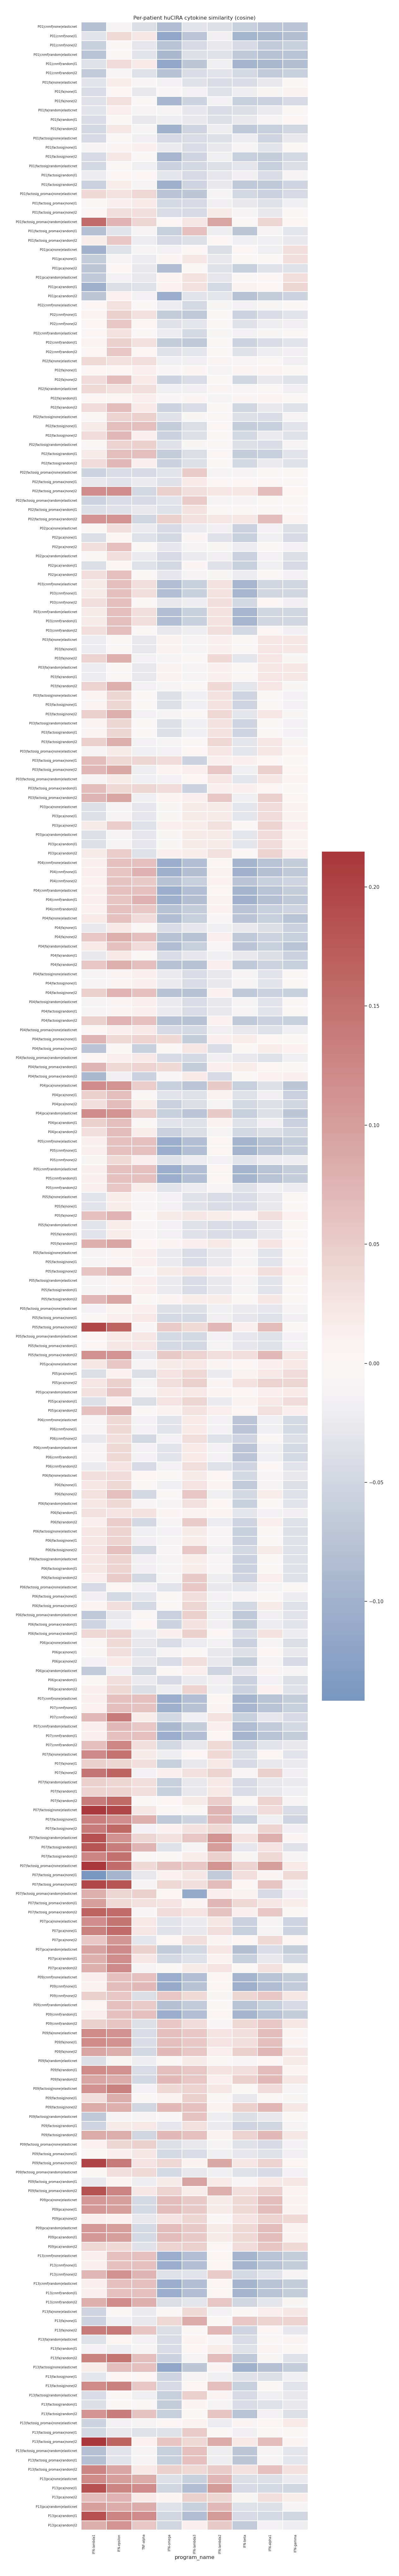

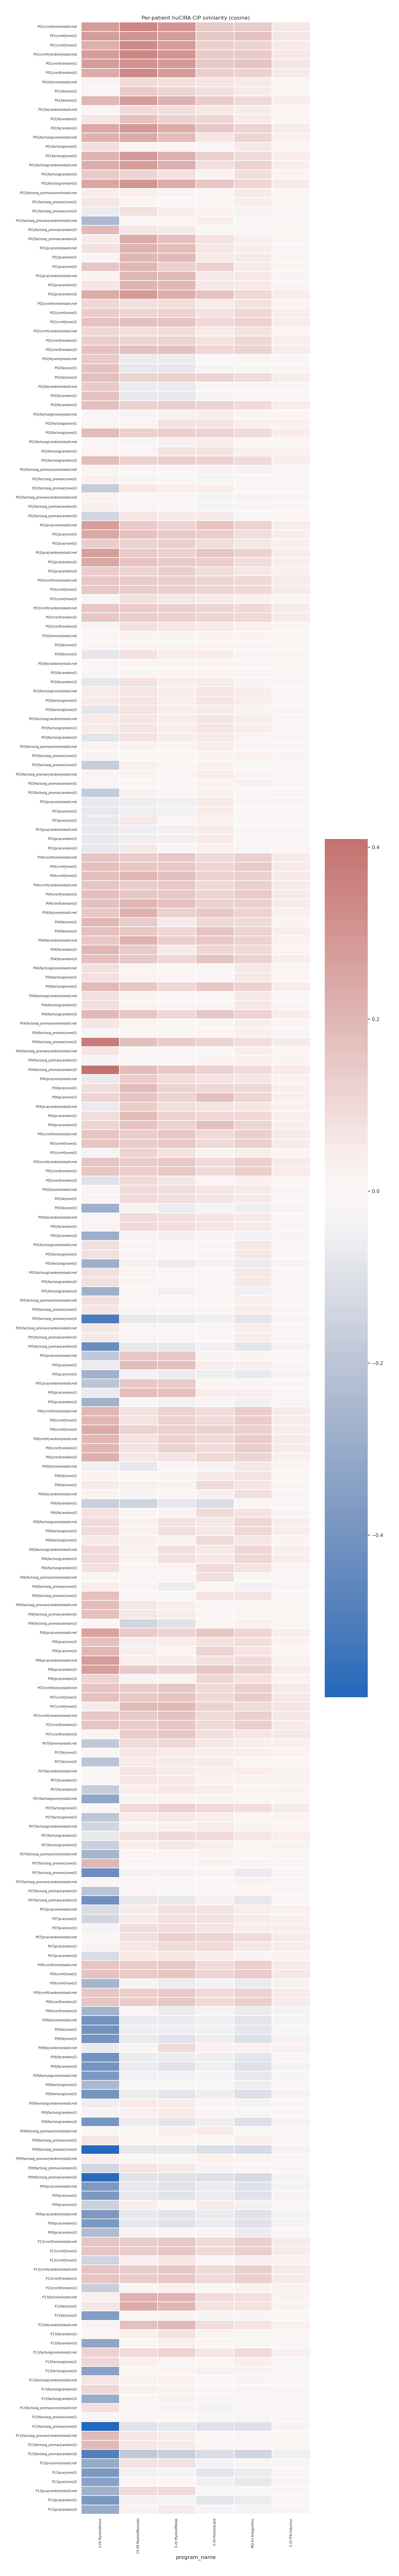

,method,downsampling,penalty,n_patients,mean_pairwise_hucira_profile_corr,sd_pairwise_hucira_profile_corr
0,cnmf,none,elasticnet,9,0.760913,0.221221
1,cnmf,none,l1,9,0.889556,0.173759
2,cnmf,none,l2,9,0.512612,0.439151
3,cnmf,random,elasticnet,9,0.787110,0.198947
4,cnmf,random,l1,9,0.888154,0.174854
5,cnmf,random,l2,9,0.513879,0.434126
6,fa,none,elasticnet,9,0.183486,0.475015
7,fa,none,l1,9,0.042118,0.398934
8,fa,none,l2,9,0.611614,0.311575
9,fa,random,elasticnet,9,0.187991,0.465594


Saved huCIRA per-patient interpretation outputs to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319/per_patient_hucira_similarity__most_parsimonious_nonzero


In [5]:
# huCIRA projection of selected per-patient predictive signatures
from sc_classification.utils.hucira_interpretation import (
    DEFAULT_HUCIRA_PROGRAM_SUBSET,
    compute_signature_program_jaccard,
    compute_signature_program_similarity,
    export_hucira_reference_sets,
    load_hucira_reference_assets,
    select_reference_programs,
    summarize_top_program_matches,
)

HUCIRA_REFERENCE_DIR = Path("/home/minhang/mds_project/data/hucira_reference")
HUCIRA_AUTO_BUILD = False
HUCIRA_FOCUS_TERMS = DEFAULT_HUCIRA_PROGRAM_SUBSET
HUCIRA_TOP_K_MATCHES = 5
HUCIRA_TOP_HEATMAP_PROGRAMS = 40
HUCIRA_TOP_GENE_JACCARD_N = 200

if (HUCIRA_REFERENCE_DIR / "reference_table.csv").exists():
    hucira_assets = load_hucira_reference_assets(HUCIRA_REFERENCE_DIR)
elif HUCIRA_AUTO_BUILD:
    hucira_assets = export_hucira_reference_sets(HUCIRA_REFERENCE_DIR)
else:
    hucira_assets = None
    print(
        "HuCIRA reference assets not found. Run `python sc_classification/scripts/Relapse_MRD_DR_Classification/build_hucira_reference_sets.py` "
        "or set HUCIRA_AUTO_BUILD=True in an environment with `hucira` installed."
    )

if hucira_assets is not None:
    hucira_out = OUTPUT_DIR / f"per_patient_hucira_similarity__{SELECTION_MODE}"
    hucira_out.mkdir(parents=True, exist_ok=True)

    cytokine_ref = hucira_assets["cytokine_long"]
    cip_ref = hucira_assets["cip_long"]

    cytokine_focus = select_reference_programs(cytokine_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    cip_focus = select_reference_programs(cip_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    if cytokine_focus.empty:
        cytokine_focus = cytokine_ref.copy()
    if cip_focus.empty:
        cip_focus = cip_ref.copy()

    cytokine_scores = compute_signature_program_similarity(sig_df_pp, cytokine_focus, metrics=("cosine", "pearson"))
    cip_scores = compute_signature_program_similarity(sig_df_pp, cip_focus, metrics=("cosine", "pearson"))
    cytokine_j = compute_signature_program_jaccard(sig_df_pp, cytokine_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")
    cip_j = compute_signature_program_jaccard(sig_df_pp, cip_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")

    cytokine_top = summarize_top_program_matches(cytokine_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")
    cip_top = summarize_top_program_matches(cip_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")
    display(cytokine_top)
    display(cip_top)

    def _plot_hucira_heatmap(score_df: pd.DataFrame, title: str):
        if score_df.empty:
            return
        top_programs = score_df.abs().max(axis=0).sort_values(ascending=False).head(HUCIRA_TOP_HEATMAP_PROGRAMS).index
        mat = score_df.loc[:, top_programs]
        fig, ax = plt.subplots(figsize=(max(12, 0.35 * mat.shape[1]), max(6, 0.30 * mat.shape[0])))
        sns.heatmap(mat, cmap="vlag", center=0, linewidths=0.1, linecolor="white", ax=ax)
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        plt.tight_layout()
        plt.show()

    _plot_hucira_heatmap(cytokine_scores["cosine"], "Per-patient huCIRA cytokine similarity (cosine)")
    _plot_hucira_heatmap(cip_scores["cosine"], "Per-patient huCIRA CIP similarity (cosine)")

    cytokine_scores["cosine"].to_csv(hucira_out / "cytokine_similarity_cosine.csv")
    cytokine_scores["pearson"].to_csv(hucira_out / "cytokine_similarity_pearson.csv")
    cytokine_scores["overlap_n"].to_csv(hucira_out / "cytokine_overlap_counts.csv")
    cip_scores["cosine"].to_csv(hucira_out / "cip_similarity_cosine.csv")
    cip_scores["pearson"].to_csv(hucira_out / "cip_similarity_pearson.csv")
    cip_scores["overlap_n"].to_csv(hucira_out / "cip_overlap_counts.csv")
    cytokine_j.to_csv(hucira_out / f"cytokine_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cip_j.to_csv(hucira_out / f"cip_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cytokine_top.to_csv(hucira_out / "cytokine_top_matches.csv", index=False)
    cip_top.to_csv(hucira_out / "cip_top_matches.csv", index=False)

    # Cross-patient consistency in huCIRA space for each DR x downsampling x penalty combination.
    consistency_rows = []
    for combo, sub in selected_pp.groupby(["method", "downsampling", "penalty"], observed=False):
        model_cols = [
            f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}"
            for _, r in sub.iterrows()
            if f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}" in cytokine_scores["cosine"].index
        ]
        if len(model_cols) < 2:
            continue
        sub_scores = cytokine_scores["cosine"].loc[model_cols]
        sim = sub_scores.T.corr(method="pearson")
        vals = sim.values[np.triu_indices_from(sim.values, k=1)]
        consistency_rows.append(
            {
                "method": combo[0],
                "downsampling": combo[1],
                "penalty": combo[2],
                "n_patients": len(model_cols),
                "mean_pairwise_hucira_profile_corr": float(np.nanmean(vals)),
                "sd_pairwise_hucira_profile_corr": float(np.nanstd(vals)),
            }
        )

    hucira_consistency = pd.DataFrame(consistency_rows).sort_values(["method", "downsampling", "penalty"])
    display(hucira_consistency)
    hucira_consistency.to_csv(hucira_out / "cross_patient_hucira_profile_consistency.csv", index=False)

    print("Saved huCIRA per-patient interpretation outputs to:", hucira_out)


## huCIRA scoring cheat sheet

**What the huCIRA dictionary looks like**
- `cytokine_long` and `cip_long` are long-form reference tables with one row per `(program_name, gene)`.
- The key columns are `program_name`, `gene`, `weight`, `abs_weight`, and `n_celltypes`.
- Positive `weight` means the gene is up in that huCIRA program; negative `weight` means it is down.

**How scoring works for different data objects**
- **Cells**: build a cell x gene expression matrix, then compute one score per program per cell, for example average standardized expression of the program genes or rank-based enrichment. Output is a cell x program score matrix.
- **Factors**: either compare factor loading vectors to huCIRA program vectors in gene space, or correlate cell-level factor scores with cell-level huCIRA scores. Output is a factor x program association matrix.
- **Pseudobulks**: aggregate expression by patient/timepoint/compartment, then score each pseudobulk profile against the same programs. Output is a pseudobulk x program score matrix.

**Why `HUCIRA_FOCUS_TERMS` works**
- `select_reference_programs(...)` does a case-insensitive substring match on `program_name`.
- In this notebook it keeps only programs whose names contain one of the focus terms (`IFN`, `TNF`, `IL1`, `IL10`, `IL15`, `IL32`, `Antigen`, `Myeloid`), then drops programs with fewer than 10 genes.
- That gives a compact, presentation-friendly cytokine/CIP panel instead of plotting the entire dictionary.

**How to read positive vs negative cosine similarity**
- Positive cosine: the predictive signature points in the same direction as the huCIRA program.
- Negative cosine: the predictive signature points in the opposite direction, so genes positive in that huCIRA program tend to be negative in the selected signature.
- If the sign flips across methods for one patient, check whether the magnitudes are small. Mixed signs with tiny absolute values usually mean weak/noisy alignment. Mixed signs with larger absolute values suggest that different DR/penalty choices may be selecting different biological axes.
        

,asset_name,python_type,detail
0,output_dir,PosixPath,PosixPath
1,reference_table,DataFrame,DataFrame 408202 x 9
2,cytokine_long,DataFrame,DataFrame 361688 x 9
3,cip_long,DataFrame,DataFrame 46514 x 9
4,cytokine_gene_sets_up,dict,dict with 90 entries
5,cytokine_gene_sets_down,dict,dict with 90 entries
6,cip_gene_sets_up,dict,dict with 82 entries
7,cip_gene_sets_down,dict,dict with 0 entries


### huCIRA asset examples

,program_name,n_genes,n_positive,n_negative,max_n_celltypes,aggregation_level
36,IL-15,10275,5101,5174,14,cytokine
47,IL-2,9674,4825,4849,13,cytokine
66,IL-7,9415,4672,4743,13,cytokine
22,IFN-beta,9216,4163,5053,13,cytokine
28,IFN-omega,9075,4143,4932,12,cytokine
63,IL-4,8108,3835,4273,13,cytokine
49,IL-21,7963,3969,3994,13,cytokine
24,IFN-gamma,7656,3578,4078,13,cytokine
32,IL-10,7582,3826,3756,13,cytokine
31,IL-1-beta,7353,3805,3548,14,cytokine


,program_name,n_genes,n_positive,n_negative,max_n_celltypes,aggregation_level
68,PD-04 BcellReg,2677,2677,0,1,cip
67,PD-03 BcellDiff-1,1944,1944,0,3,cip
76,SN-03 SynapticSignal,1682,1682,0,2,cip
54,IT-02 IonChannel,1565,1565,0,7,cip
12,CS-07 LymphoidHoming,1355,1355,0,3,cip
31,II-04 MyeloidActive,1290,1290,0,3,cip
13,CS-08 MyeloidRemodel,1083,1083,0,3,cip
8,CS-03 MixedCytokine,1055,1055,0,1,cip
60,MD-06 IntegrinSignal,1045,1045,0,1,cip
81,TR-04 AntiInflam,1015,1015,0,1,cip


,source,program_type,aggregation_level,program_name,gene,weight,abs_weight,n_rows,n_celltypes
0,cytokine,cytokine,cytokine,IFN-alpha1,A2M-AS1,-0.421213,0.421213,2,2
1,cytokine,cytokine,cytokine,IFN-alpha1,AAGAB,0.130394,0.130394,1,1
2,cytokine,cytokine,cytokine,IFN-alpha1,AAK1,-0.104928,0.104928,1,1
3,cytokine,cytokine,cytokine,IFN-alpha1,AAMDC,-0.137540,0.137540,1,1
4,cytokine,cytokine,cytokine,IFN-alpha1,AARS1,0.282611,0.282611,5,5
5,cytokine,cytokine,cytokine,IFN-alpha1,AARS2,0.222810,0.222810,2,2
6,cytokine,cytokine,cytokine,IFN-alpha1,AARSD1,-0.225931,0.225931,1,1
7,cytokine,cytokine,cytokine,IFN-alpha1,AASDH,-0.190678,0.190678,3,3
8,cytokine,cytokine,cytokine,IFN-alpha1,AASDHPPT,-0.215091,0.215091,3,3
9,cytokine,cytokine,cytokine,IFN-alpha1,AASS,-0.290663,0.290663,2,2


,source,program_type,aggregation_level,program_name,gene,weight,abs_weight,n_rows,n_celltypes
0,cip,cip,cip,CS-08 MyeloidRemodel,ABCA1,0.407941,0.407941,3,3
1,cip,cip,cip,CS-08 MyeloidRemodel,ABCC6,0.237397,0.237397,3,3
2,cip,cip,cip,CS-08 MyeloidRemodel,ABHD17C,0.727070,0.727070,3,3
3,cip,cip,cip,CS-08 MyeloidRemodel,ACER3,0.173191,0.173191,3,3
4,cip,cip,cip,CS-08 MyeloidRemodel,ACOD1,0.362113,0.362113,3,3
5,cip,cip,cip,CS-08 MyeloidRemodel,ACSL1,0.337390,0.337390,3,3
6,cip,cip,cip,CS-08 MyeloidRemodel,ACSL4,0.113448,0.113448,3,3
7,cip,cip,cip,CS-08 MyeloidRemodel,ACSL5,0.194016,0.194016,3,3
8,cip,cip,cip,CS-08 MyeloidRemodel,ACTN1,0.385129,0.385129,3,3
9,cip,cip,cip,CS-08 MyeloidRemodel,ACVR1,0.119242,0.119242,3,3


### Focus-term to program mapping

,reference,focus_term,n_matching_programs,example_programs
0,cytokine,IFN,8,IFN-alpha1; IFN-beta; IFN-epsilon; IFN-gamma; ...
1,cytokine,TNF,1,TNF-alpha
2,cytokine,IL1,0,
3,cytokine,IL10,0,
4,cytokine,IL15,0,
5,cytokine,IL32,0,
6,cytokine,Antigen,0,
7,cytokine,Myeloid,0,
8,cip,IFN,1,II-25 IFN-Induction
9,cip,TNF,0,


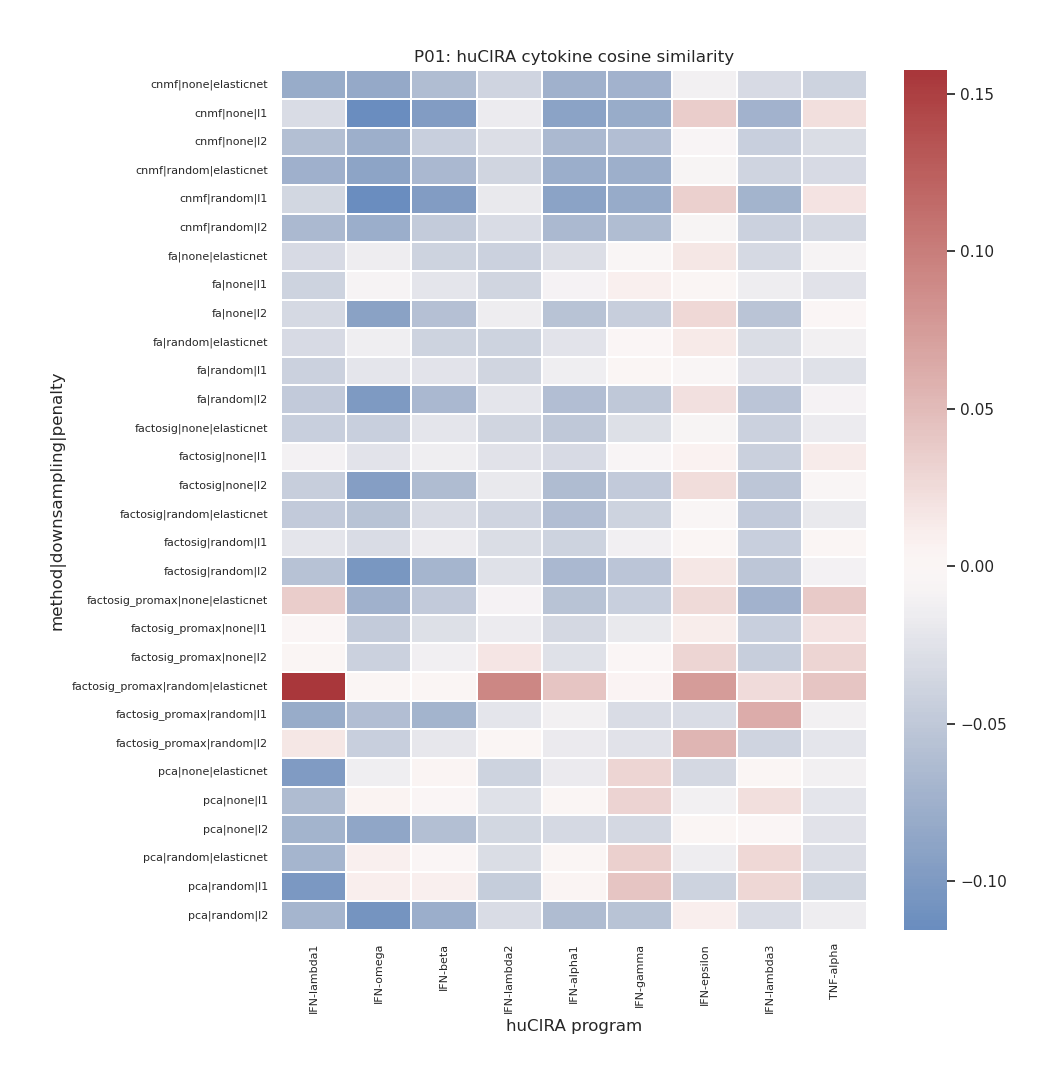

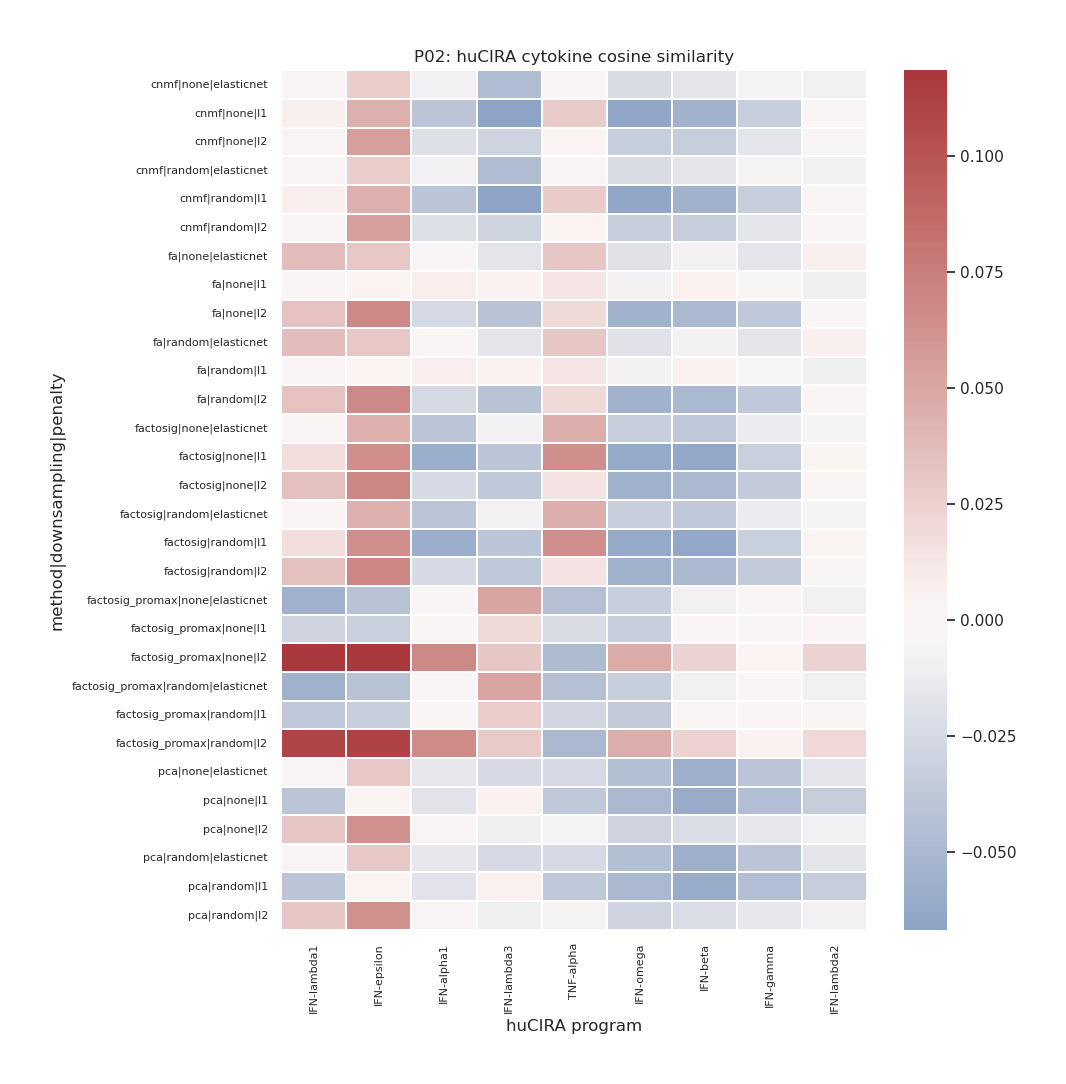

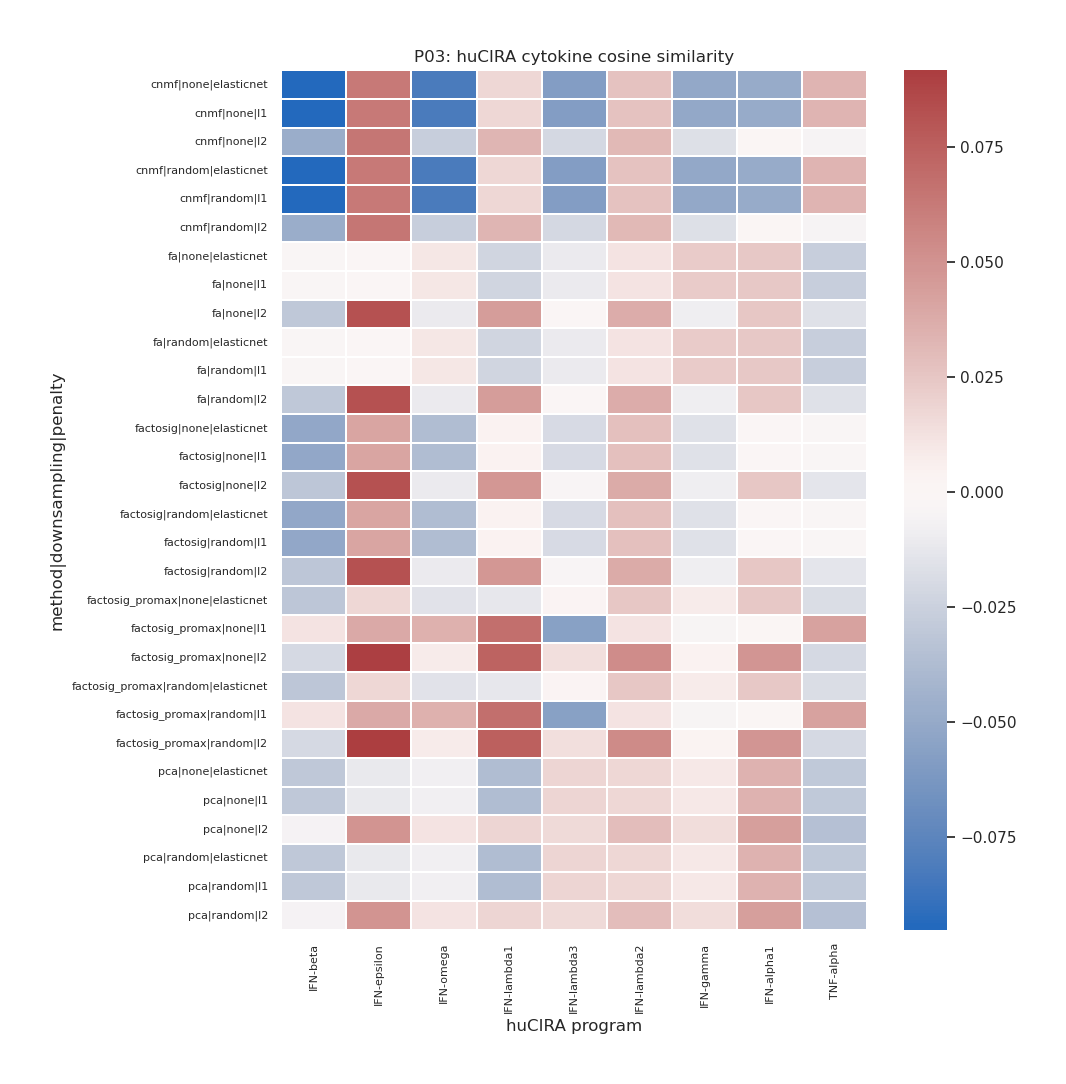

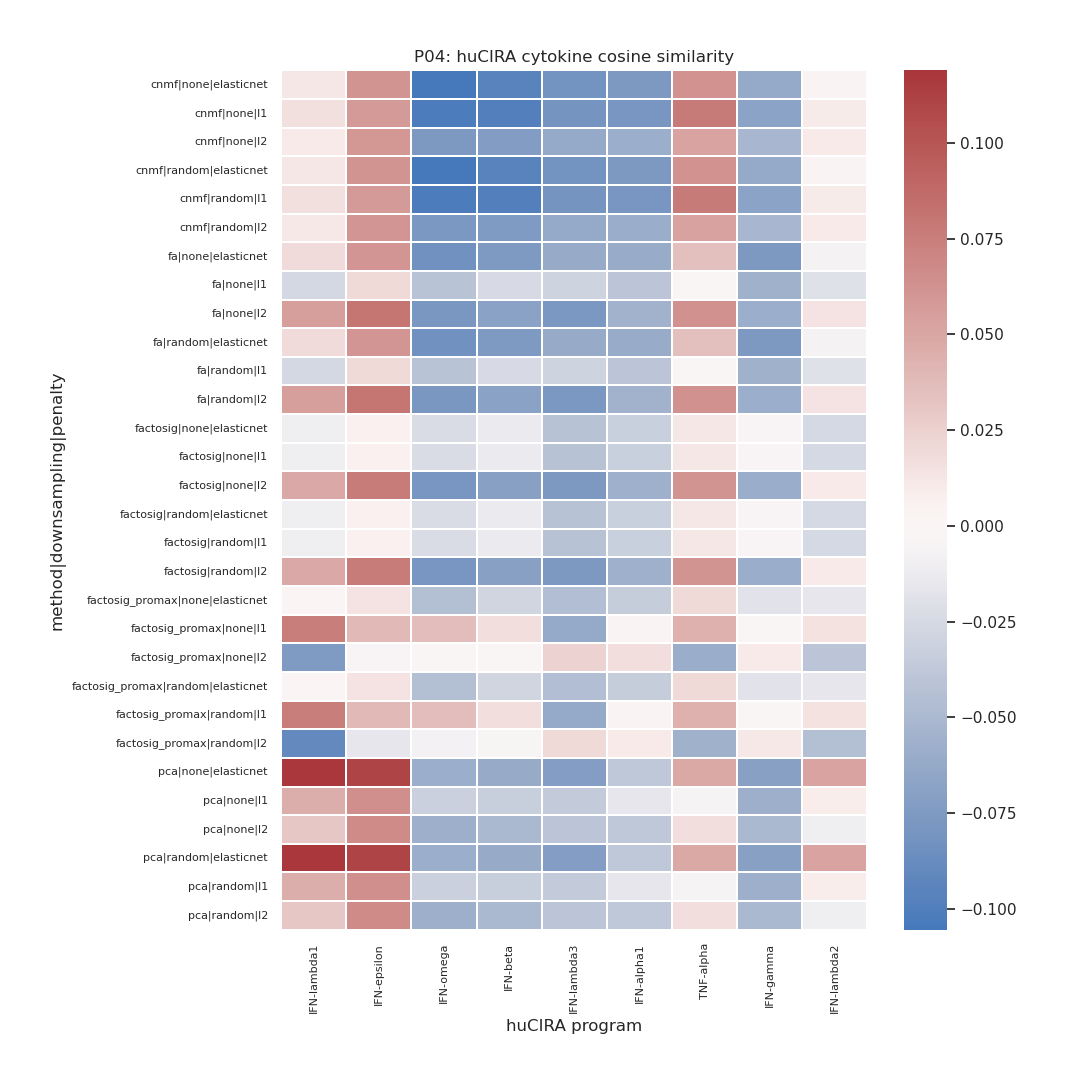

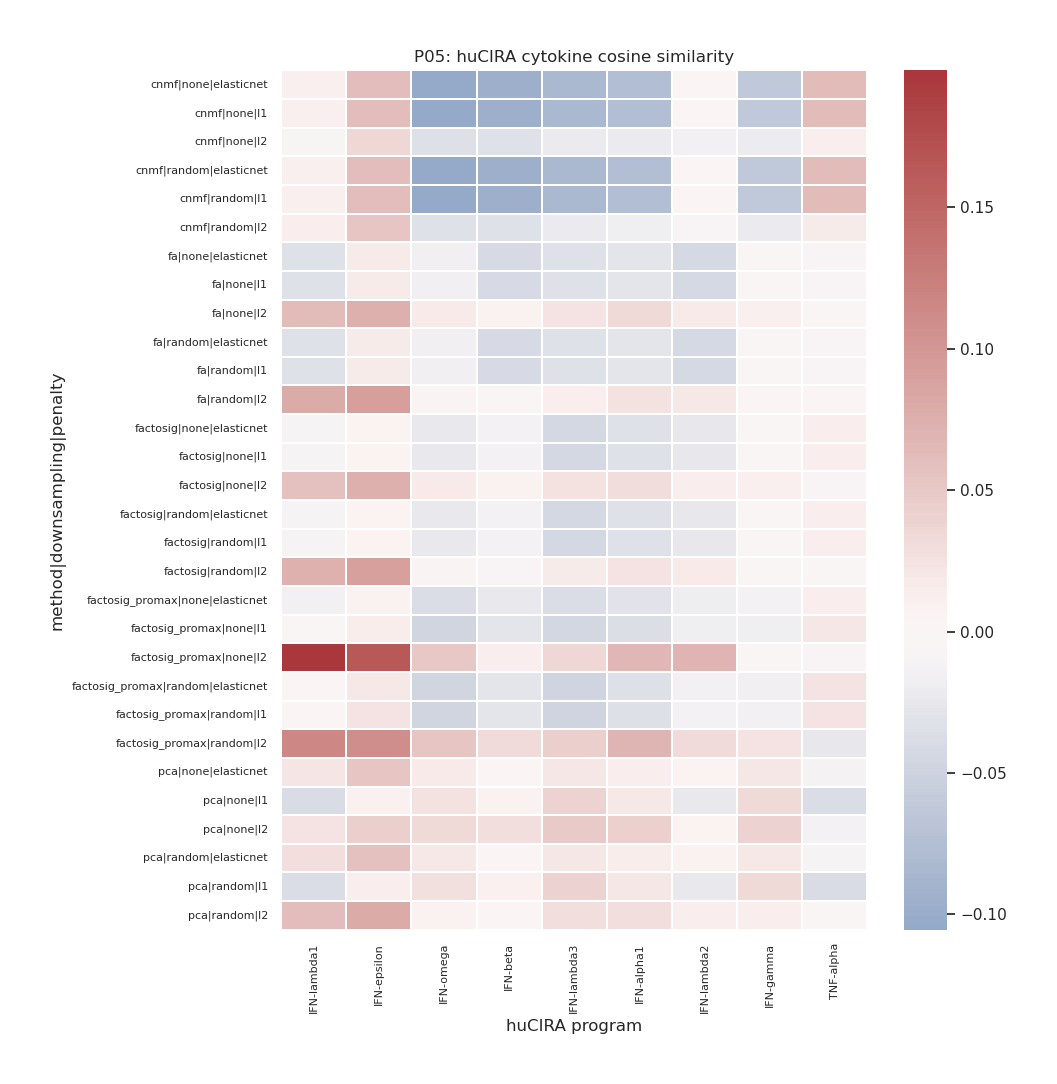

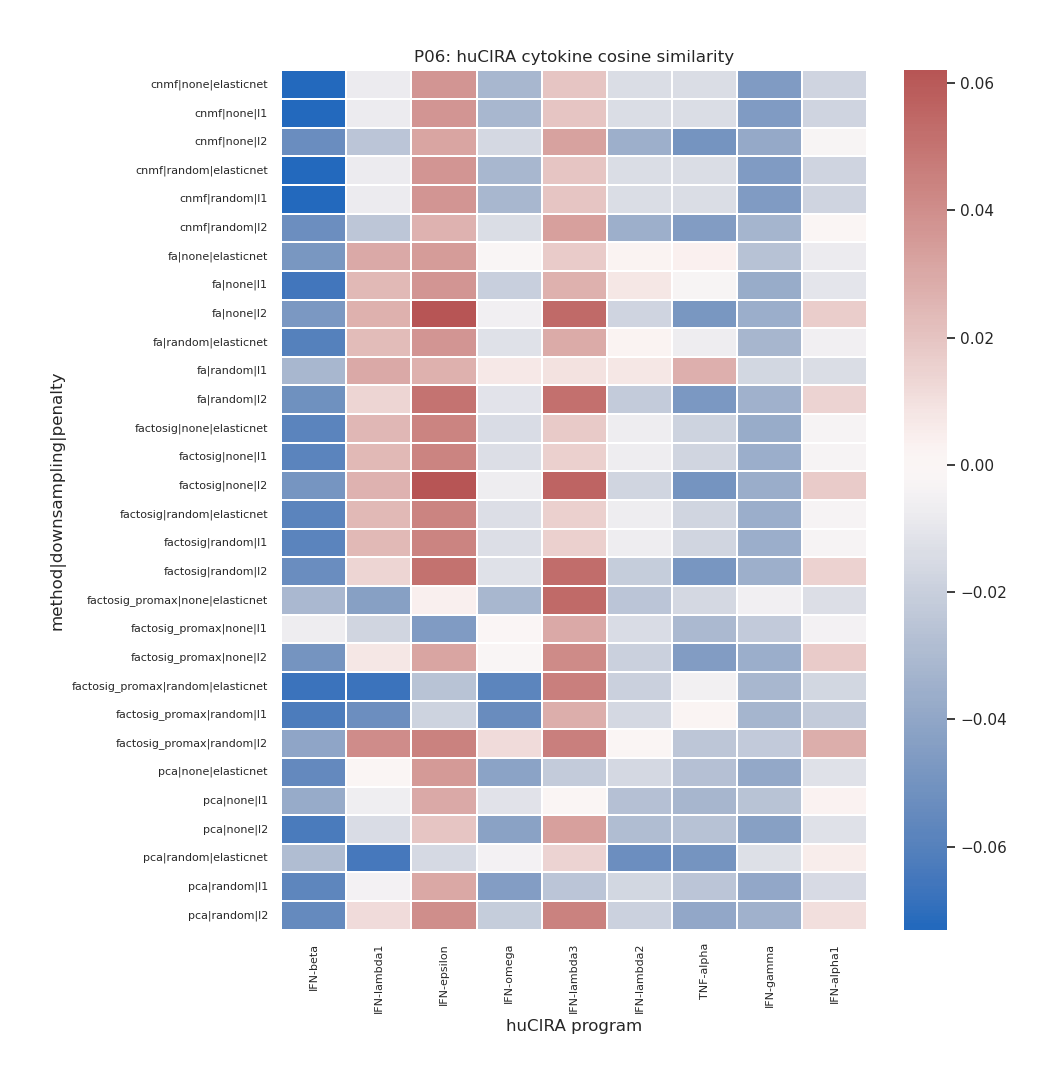

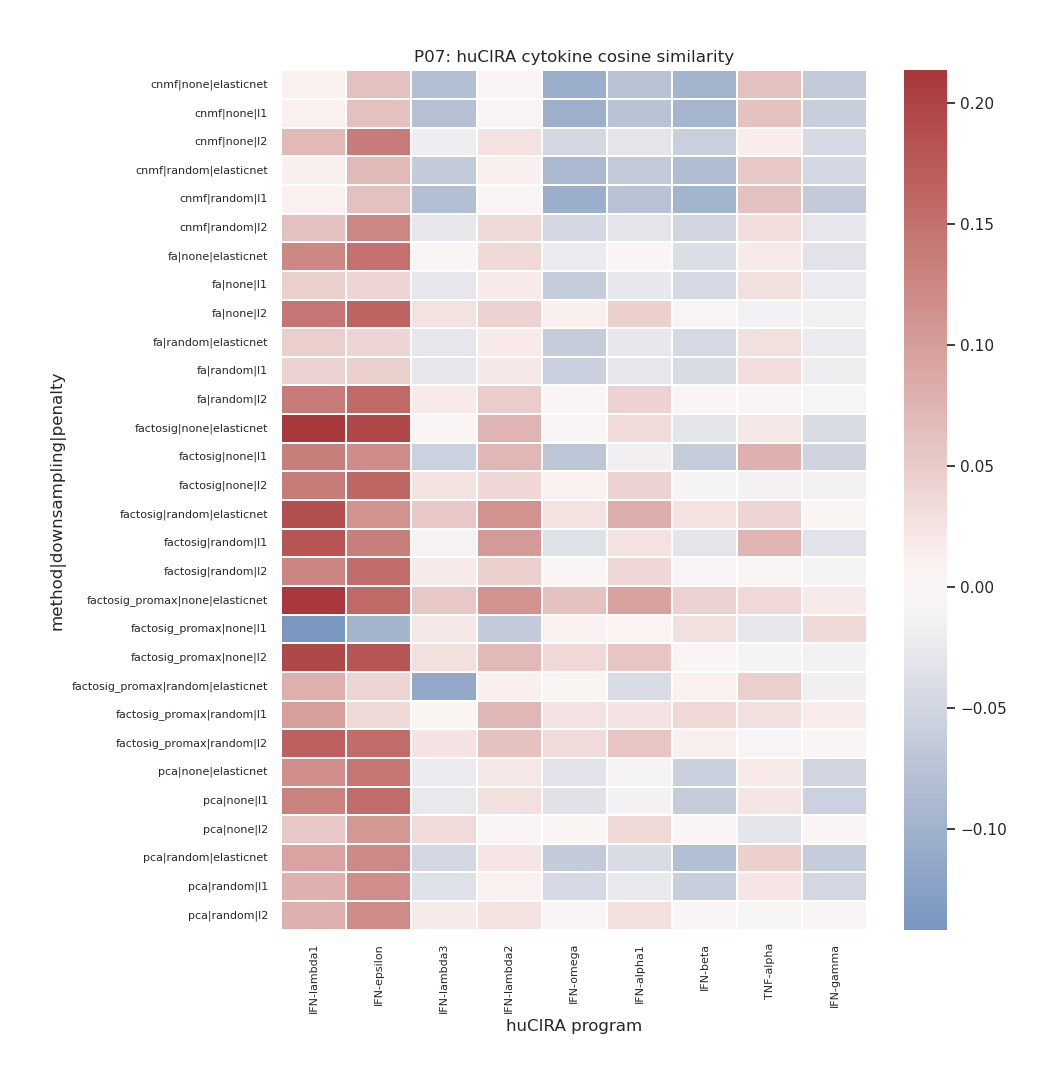

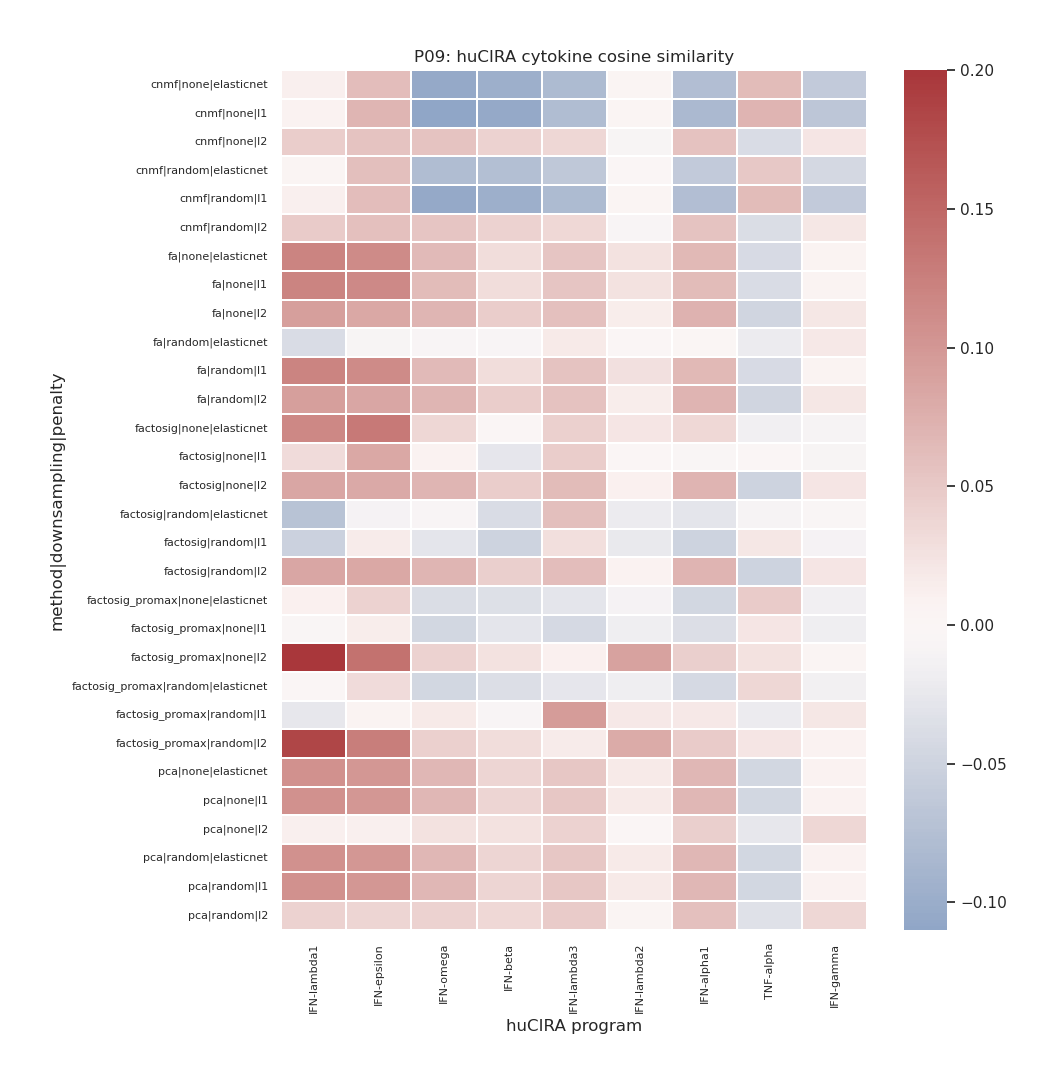

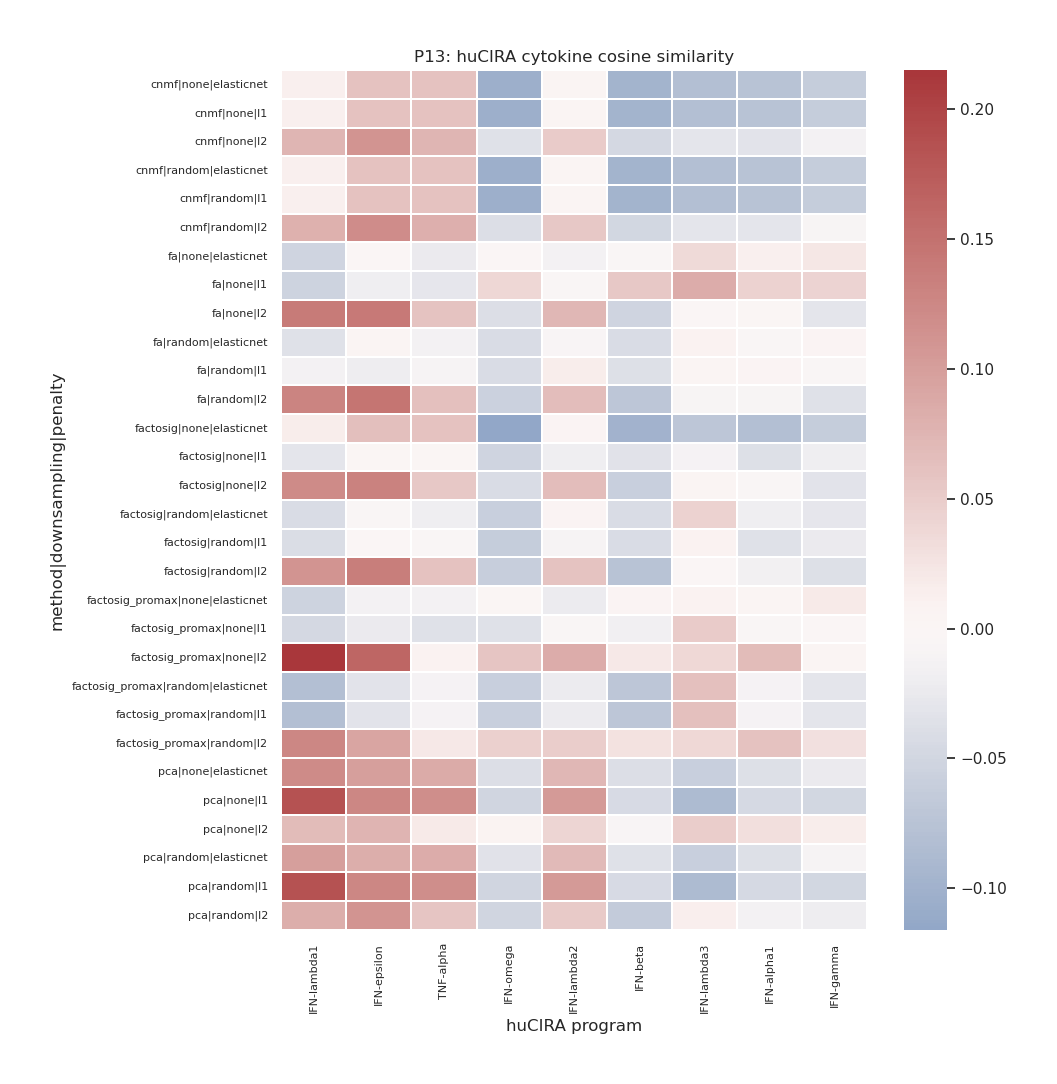

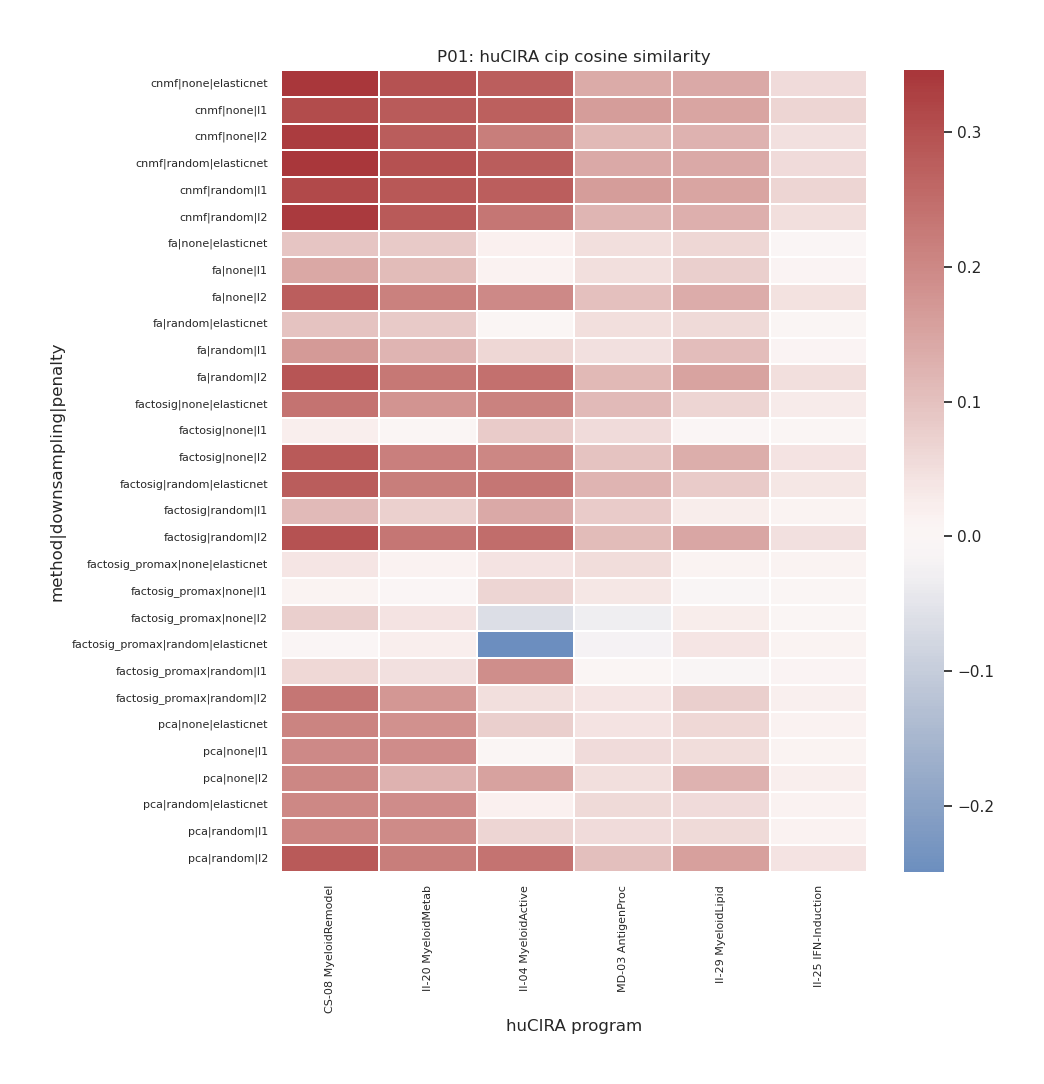

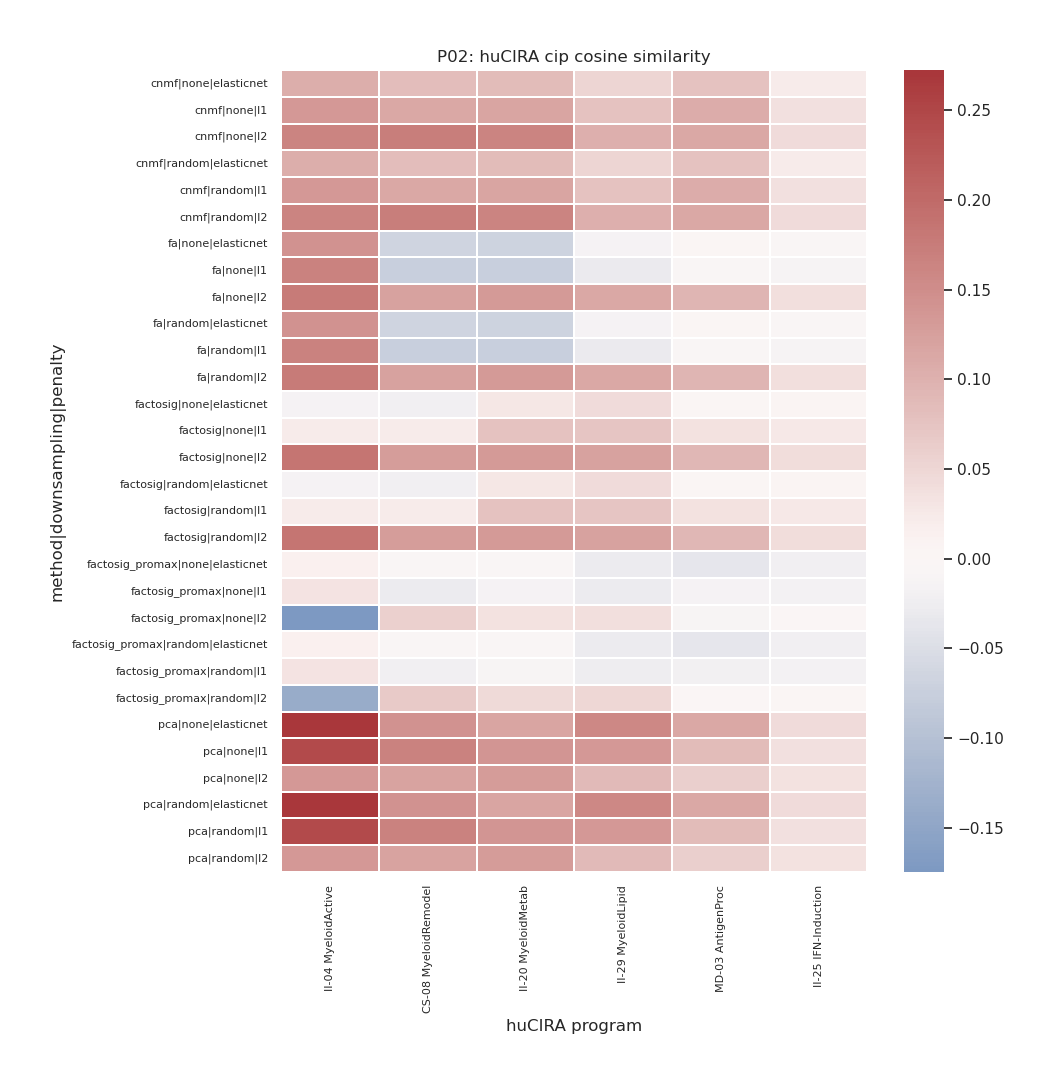

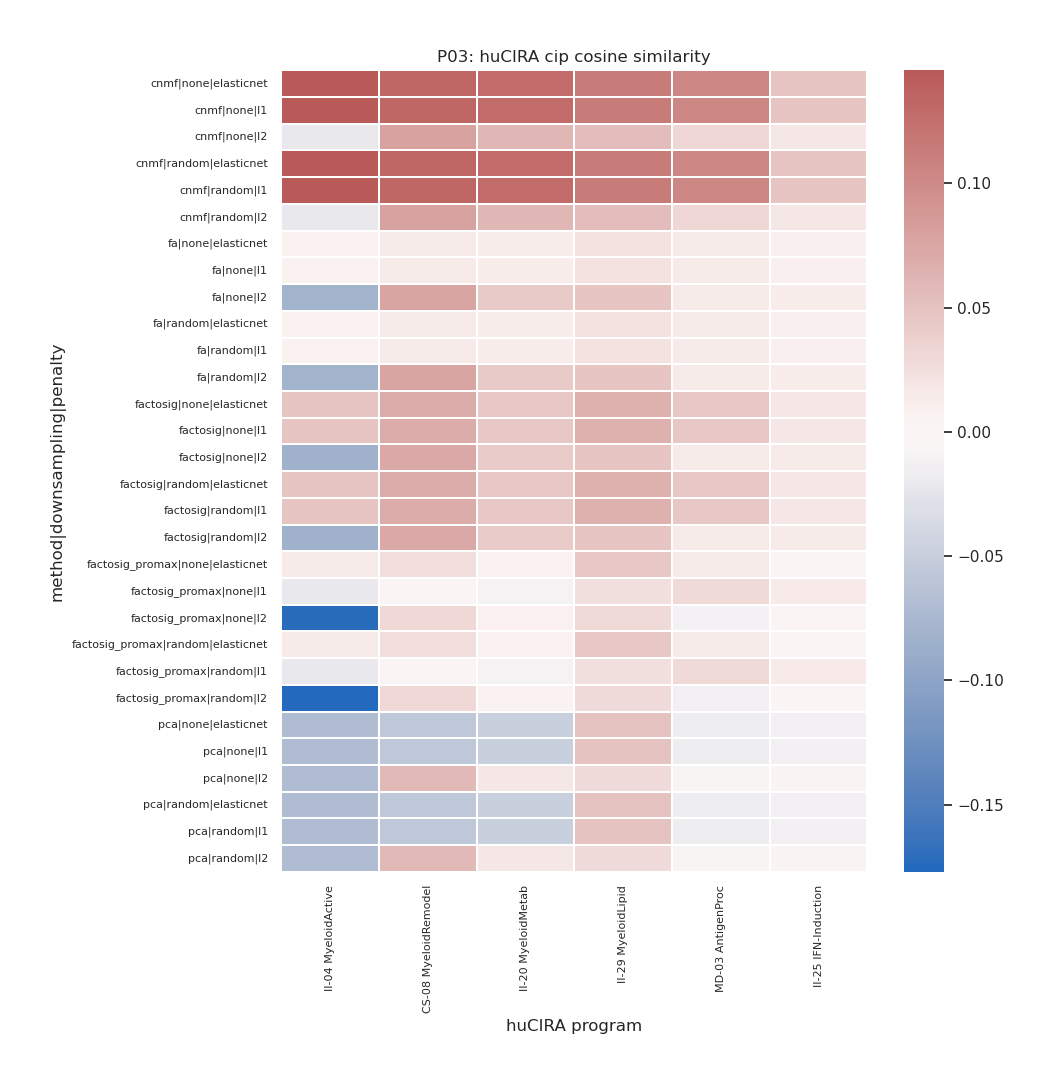

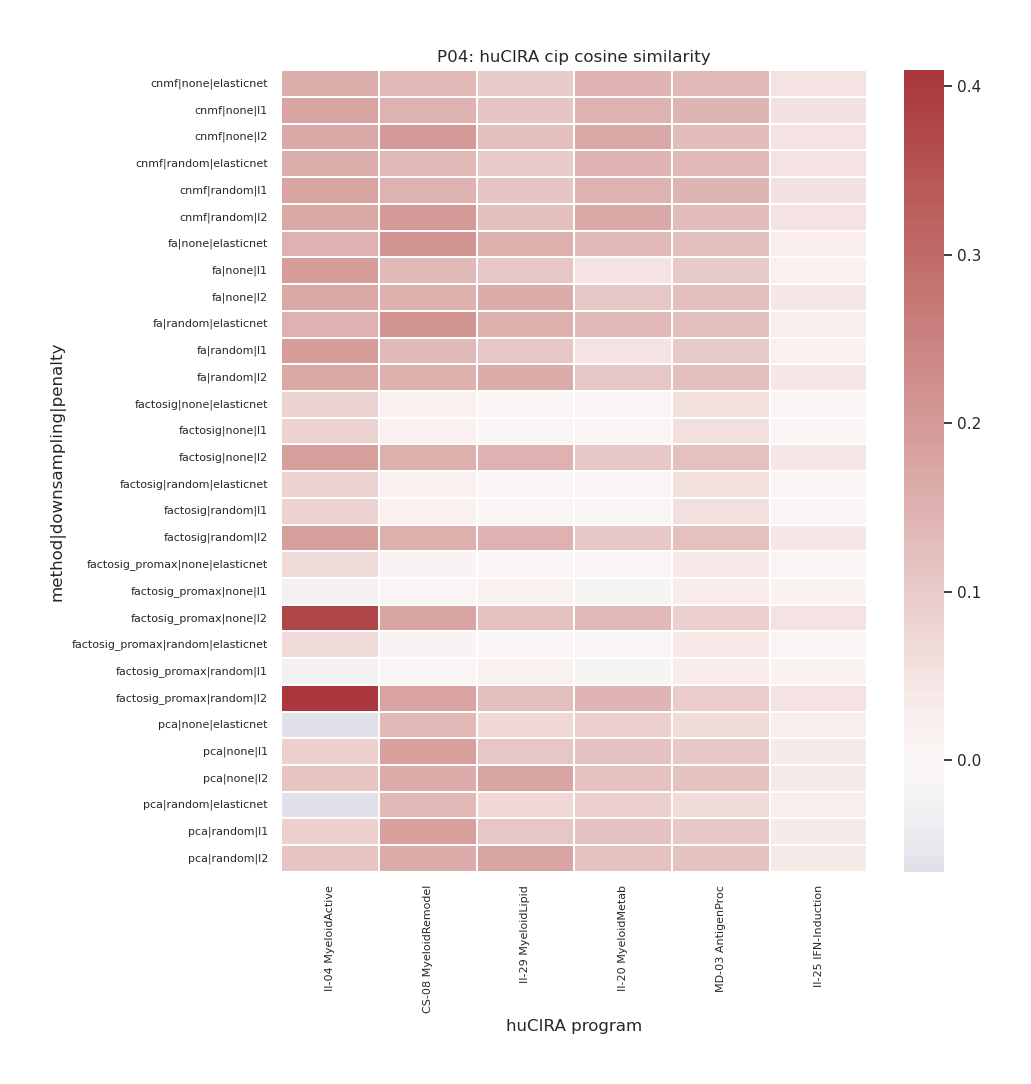

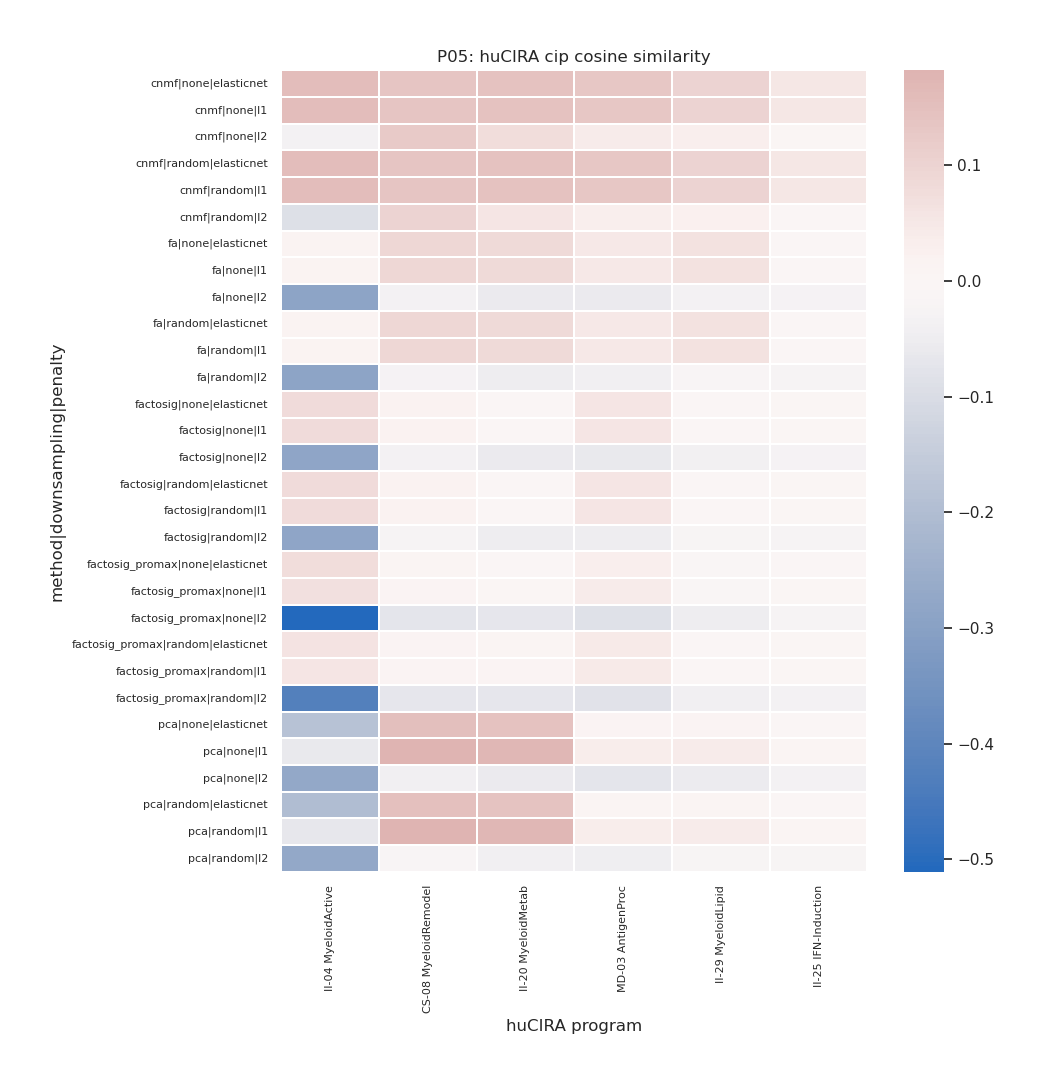

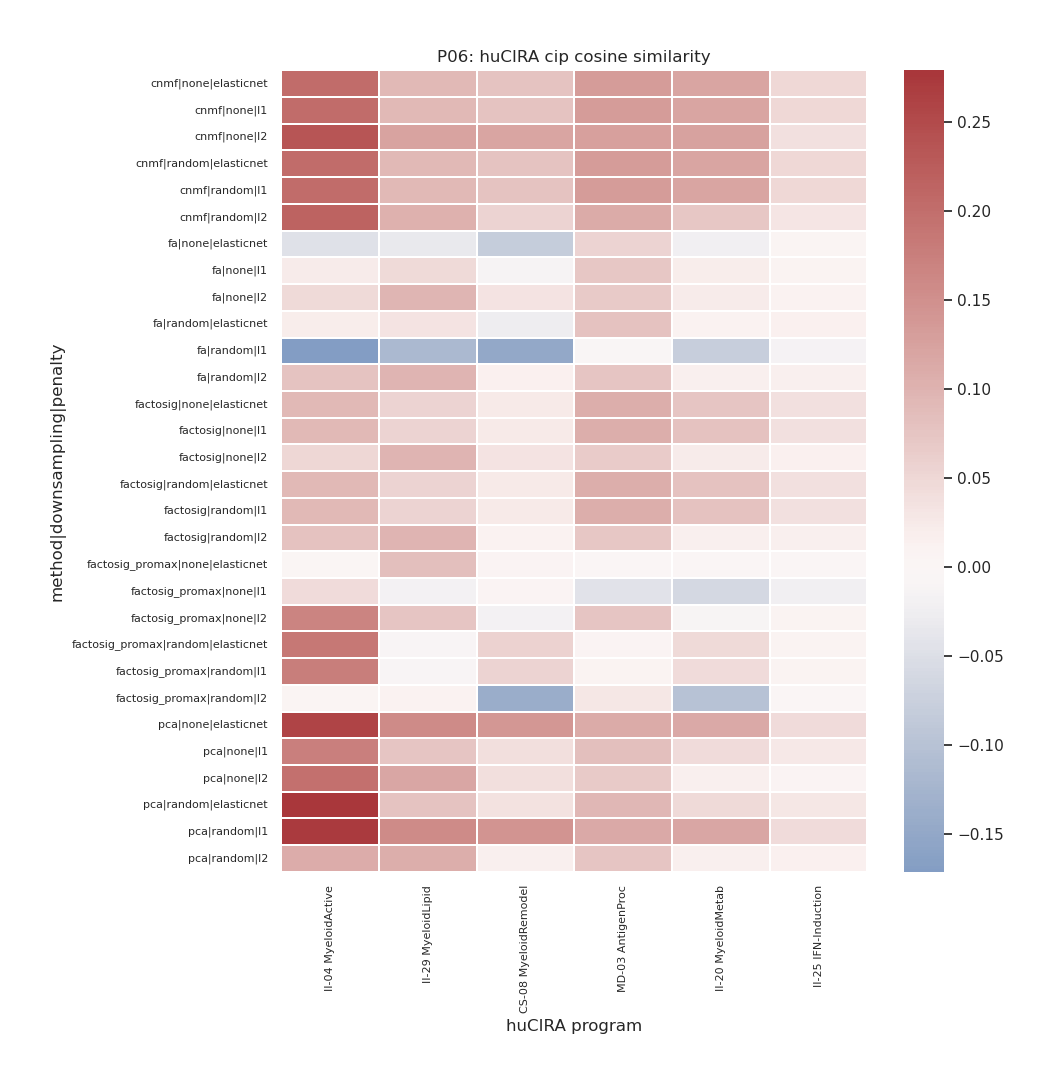

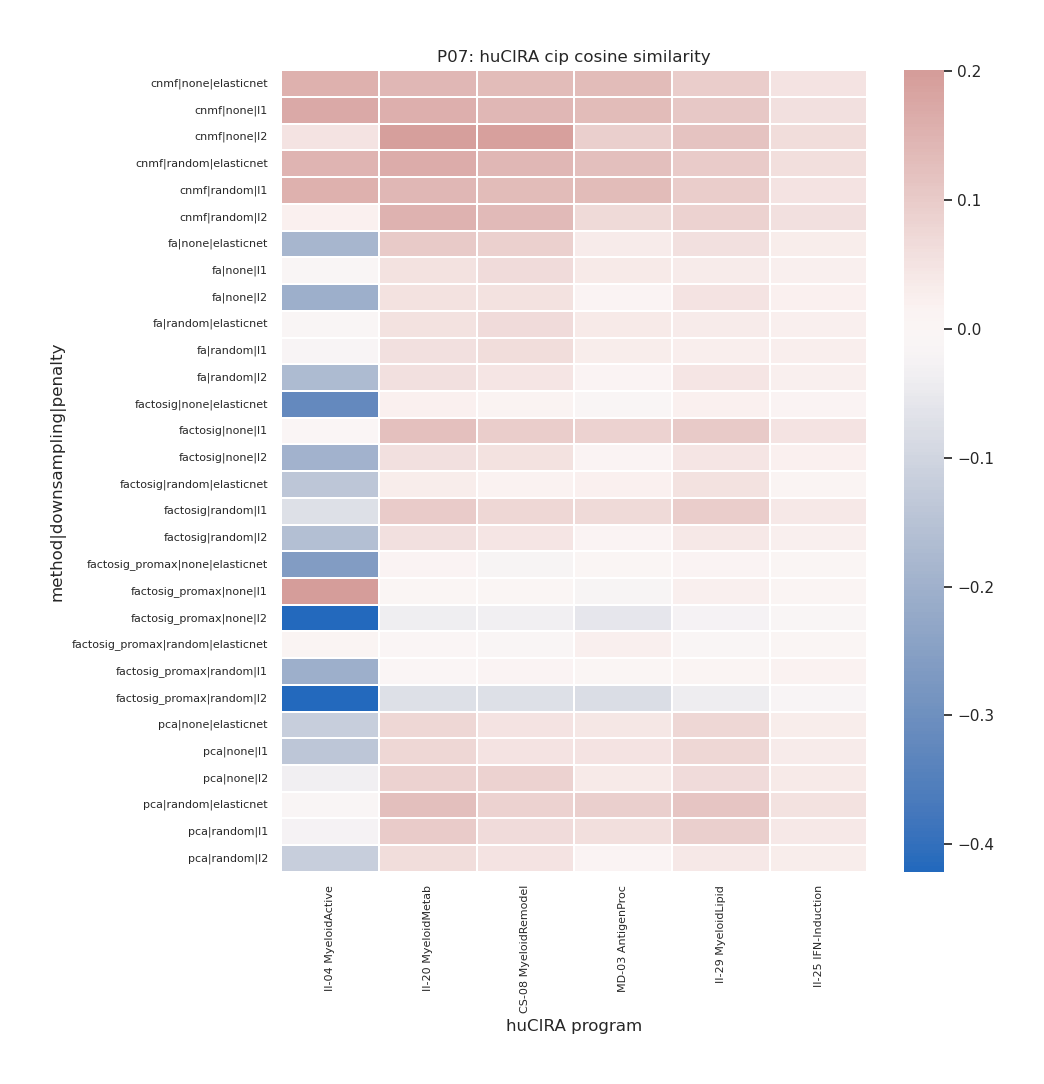

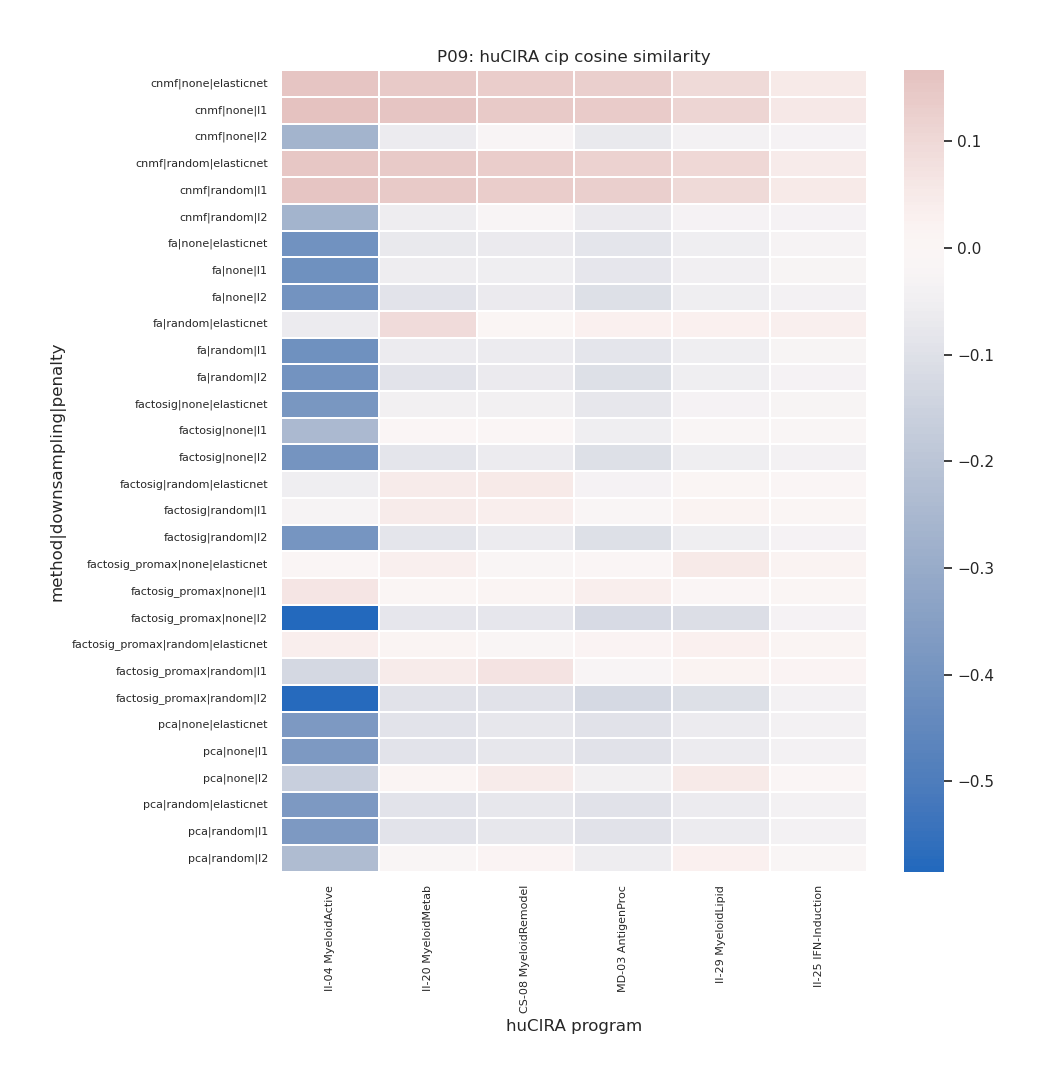

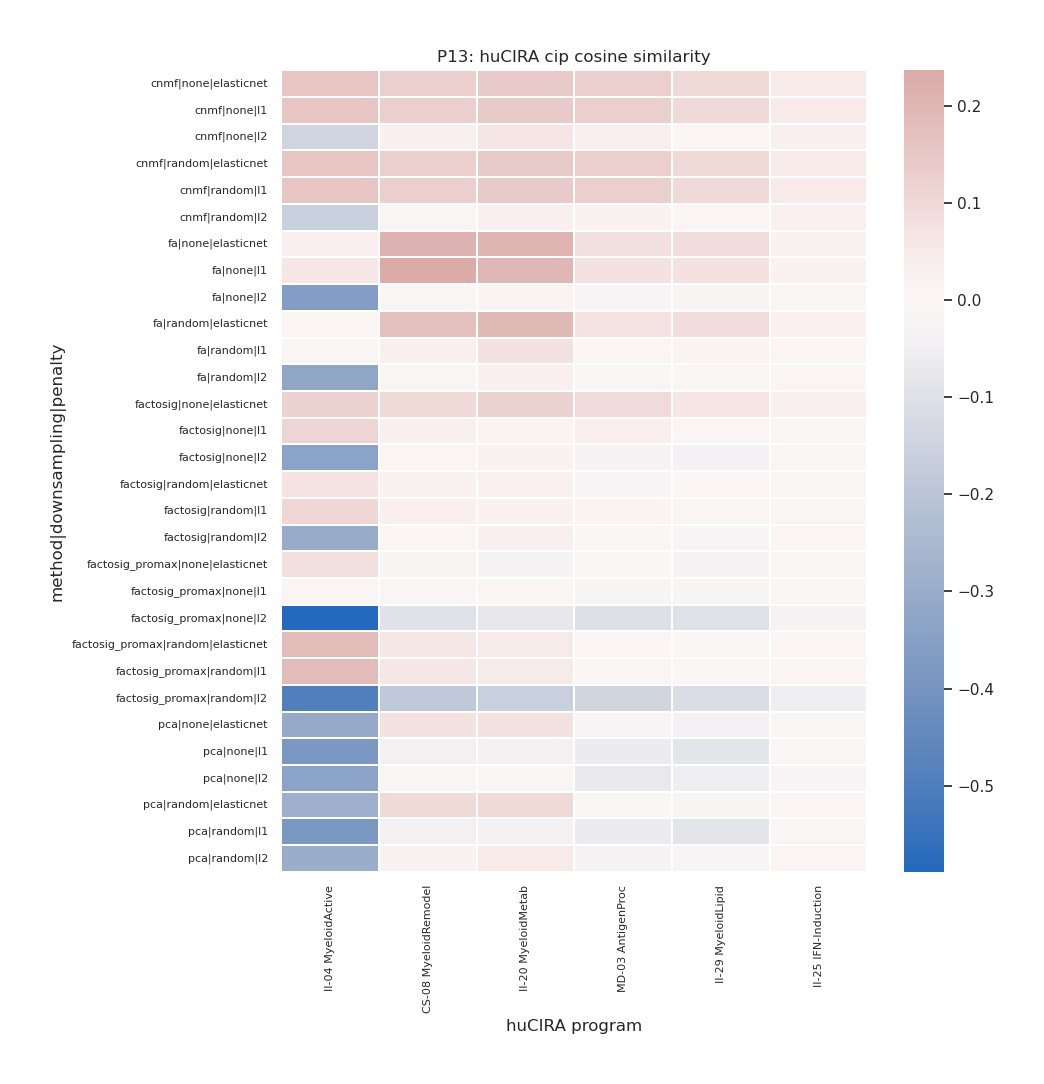

### Patient x cytokine program summary

,patient,program_name,n_models,mean_cosine,median_cosine,max_abs_cosine,min_cosine,max_cosine,mean_pearson,mean_overlap_n,n_positive,n_negative,sign_consistency,interpretation_flag
4,P01,IFN-lambda1,30,-0.038245,-0.043753,0.157478,-0.102169,0.157478,-0.027658,1428.400000,4,26,0.733333,mixed_sign_and_directionally_unstable
7,P01,IFN-omega,30,-0.053476,-0.050829,0.115410,-0.115410,0.010649,-0.035349,2797.133333,4,26,0.733333,mixed_sign_and_directionally_unstable
1,P01,IFN-beta,30,-0.039499,-0.039715,0.097957,-0.097957,0.009932,-0.021742,2887.400000,3,27,0.800000,mixed_sign_but_weak
5,P01,IFN-lambda2,30,-0.022733,-0.029199,0.092867,-0.045578,0.092867,-0.020176,690.133333,3,27,0.800000,mixed_sign_but_weak
0,P01,IFN-alpha1,30,-0.039440,-0.037306,0.090587,-0.090587,0.041991,-0.023993,2028.533333,3,27,0.800000,mixed_sign_but_weak
3,P01,IFN-gamma,30,-0.025860,-0.028978,0.081486,-0.081486,0.041841,-0.016569,2494.133333,7,23,0.533333,mixed_sign_but_weak
2,P01,IFN-epsilon,30,0.007877,0.004444,0.075642,-0.038746,0.075642,0.006516,1567.933333,18,12,0.200000,mixed_sign_but_weak
6,P01,IFN-lambda3,30,-0.028466,-0.039388,0.073186,-0.073186,0.062521,-0.022726,1708.866667,6,24,0.600000,mixed_sign_but_weak
8,P01,TNF-alpha,30,-0.008477,-0.011441,0.041399,-0.039021,0.041399,-0.017807,954.133333,8,22,0.466667,mixed_sign_but_weak
13,P02,IFN-lambda1,30,0.010046,0.003015,0.118408,-0.055235,0.118408,0.023444,1425.600000,22,8,0.466667,mixed_sign_and_directionally_unstable


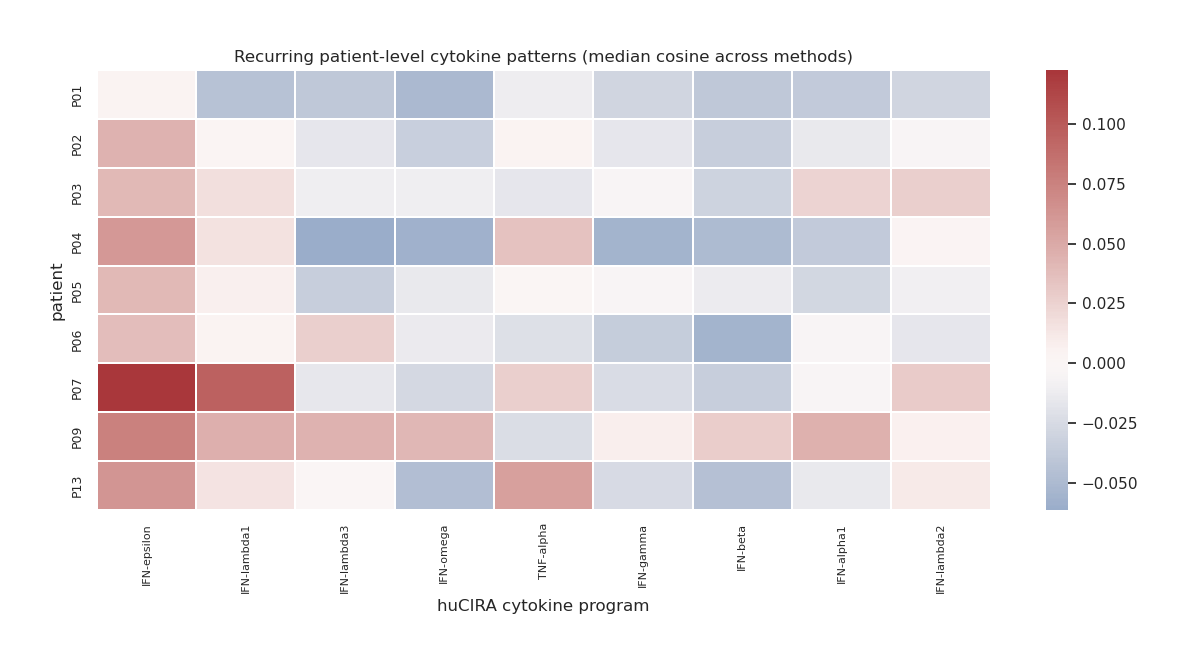

### Recurring cytokine programs across patients

,program_name,n_patients,n_patients_mean_positive,n_patients_mean_negative,mean_abs_patient_median,mean_sign_consistency
2,IFN-epsilon,9,1,0,0.054340,0.696296
1,IFN-beta,9,0,0,0.036726,0.651852
7,IFN-omega,9,0,0,0.033008,0.562963
6,IFN-lambda3,9,0,0,0.027803,0.414815
4,IFN-lambda1,9,0,0,0.027645,0.444444
0,IFN-alpha1,9,0,0,0.023585,0.444444
3,IFN-gamma,9,0,0,0.022568,0.548148
8,TNF-alpha,9,0,0,0.021721,0.400000
5,IFN-lambda2,9,0,0,0.015365,0.525926


### Patient-program pairs with sign flips across methods

,patient,program_name,n_models,mean_cosine,median_cosine,max_abs_cosine,min_cosine,max_cosine,mean_pearson,mean_overlap_n,n_positive,n_negative,sign_consistency,interpretation_flag,cosine_range
58,P07,IFN-lambda1,30,0.095851,0.096527,0.213653,-0.141611,0.213653,0.113644,1420.966667,29,1,0.933333,mixed_sign_and_directionally_unstable,0.355265
76,P13,IFN-lambda1,30,0.042344,0.014449,0.214801,-0.080290,0.214801,0.053474,1416.933333,19,11,0.266667,mixed_sign_and_directionally_unstable,0.295091
56,P07,IFN-epsilon,30,0.108201,0.122586,0.196784,-0.096821,0.196784,0.114030,1559.333333,29,1,0.933333,mixed_sign_and_directionally_unstable,0.293605
67,P09,IFN-lambda1,30,0.056122,0.046663,0.200057,-0.070117,0.200057,0.050204,1423.533333,24,6,0.600000,mixed_sign_and_directionally_unstable,0.270174
4,P01,IFN-lambda1,30,-0.038245,-0.043753,0.157478,-0.102169,0.157478,-0.027658,1428.400000,4,26,0.733333,mixed_sign_and_directionally_unstable,0.259646
40,P05,IFN-lambda1,30,0.017178,0.007237,0.198462,-0.039127,0.198462,0.017018,1416.933333,17,13,0.133333,mixed_sign_and_directionally_unstable,0.237589
31,P04,IFN-lambda1,30,0.020216,0.015678,0.118970,-0.089867,0.118970,0.041199,1419.333333,22,8,0.466667,mixed_sign_and_directionally_unstable,0.208837
74,P13,IFN-epsilon,30,0.061088,0.062684,0.164127,-0.031965,0.164127,0.065224,1555.000000,22,8,0.466667,mixed_sign_and_directionally_unstable,0.196091
70,P09,IFN-omega,30,0.016661,0.041554,0.109878,-0.109878,0.070058,-0.024233,2784.733333,20,10,0.333333,mixed_sign_and_directionally_unstable,0.179936
69,P09,IFN-lambda3,30,0.022922,0.044877,0.096099,-0.081917,0.096099,0.012336,1704.666667,23,7,0.533333,mixed_sign_but_weak,0.178016


### P13 cytokine score detail

,model_uid,program_name,cosine_similarity,pearson_correlation,overlap_n,patient,method,downsampling,penalty,model_label,reference_type
2268,P13|factosig|none|elasticnet,IFN-alpha1,-0.080043,-0.034701,2045,P13,factosig,none,elasticnet,factosig|none|elasticnet,cytokine
2187,P13|cnmf|random|elasticnet,IFN-alpha1,-0.076151,-0.018135,1783,P13,cnmf,random,elasticnet,cnmf|random|elasticnet,cytokine
2169,P13|cnmf|none|l1,IFN-alpha1,-0.076151,-0.018135,1783,P13,cnmf,none,l1,cnmf|none|l1,cytokine
2196,P13|cnmf|random|l1,IFN-alpha1,-0.076151,-0.018135,1783,P13,cnmf,random,l1,cnmf|random|l1,cytokine
2160,P13|cnmf|none|elasticnet,IFN-alpha1,-0.076151,-0.018135,1783,P13,cnmf,none,elasticnet,cnmf|none|elasticnet,cytokine
2412,P13|pca|random|l1,IFN-alpha1,-0.046067,-0.051235,2045,P13,pca,random,l1,pca|random|l1,cytokine
2385,P13|pca|none|l1,IFN-alpha1,-0.046067,-0.051235,2045,P13,pca,none,l1,pca|none|l1,cytokine
2403,P13|pca|random|elasticnet,IFN-alpha1,-0.038235,-0.038455,2045,P13,pca,random,elasticnet,pca|random|elasticnet,cytokine
2376,P13|pca|none|elasticnet,IFN-alpha1,-0.038145,-0.039882,2045,P13,pca,none,elasticnet,pca|none|elasticnet,cytokine
2277,P13|factosig|none|l1,IFN-alpha1,-0.038140,-0.033541,2045,P13,factosig,none,l1,factosig|none|l1,cytokine


### Presentation suggestions

,takeaway
0,Use the per-patient heatmaps for presentation ...
1,Use the patient x program median-cosine heatma...
2,Use the sign-flip table to separate robust pos...
3,Interpret strong positive or negative scores t...


Saved huCIRA presentation views to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319/per_patient_hucira_similarity__most_parsimonious_nonzero/presentation_views


In [ ]:
from IPython.display import Markdown, display

if hucira_assets is None:
    raise RuntimeError("Run the huCIRA projection cell above first so that hucira_assets and the score tables exist.")

presentation_out = hucira_out / "presentation_views"
presentation_out.mkdir(parents=True, exist_ok=True)


def _summarize_asset(name: str, obj) -> dict[str, object]:
    if isinstance(obj, pd.DataFrame):
        detail = f"DataFrame {obj.shape[0]} x {obj.shape[1]}"
    elif isinstance(obj, dict):
        detail = f"dict with {len(obj)} entries"
    else:
        detail = type(obj).__name__
    return {"asset_name": name, "python_type": type(obj).__name__, "detail": detail}


def _focus_match_summary(reference_df: pd.DataFrame, label: str) -> pd.DataFrame:
    programs = sorted(reference_df["program_name"].dropna().astype(str).unique())
    rows = []
    for term in HUCIRA_FOCUS_TERMS:
        matches = [p for p in programs if term.lower() in p.lower()]
        rows.append(
            {
                "reference": label,
                "focus_term": term,
                "n_matching_programs": len(matches),
                "example_programs": "; ".join(matches[:8]),
            }
        )
    return pd.DataFrame(rows)


def _program_catalog(reference_df: pd.DataFrame) -> pd.DataFrame:
    out = (
        reference_df.groupby("program_name", observed=False)
        .agg(
            n_genes=("gene", "size"),
            n_positive=("weight", lambda s: int((s > 0).sum())),
            n_negative=("weight", lambda s: int((s < 0).sum())),
            max_n_celltypes=("n_celltypes", "max"),
            aggregation_level=("aggregation_level", "first"),
        )
        .reset_index()
        .sort_values(["n_genes", "program_name"], ascending=[False, True])
    )
    return out


def _parse_model_uid(model_uid: str) -> dict[str, str]:
    patient, method, downsampling, penalty = model_uid.split("|", 3)
    return {
        "model_uid": model_uid,
        "patient": patient,
        "method": method,
        "downsampling": downsampling,
        "penalty": penalty,
        "model_label": f"{method}|{downsampling}|{penalty}",
    }


def _score_matrix_to_long(score_dict: dict[str, pd.DataFrame], label: str) -> pd.DataFrame:
    cosine_long = (
        score_dict["cosine"]
        .stack()
        .rename("cosine_similarity")
        .rename_axis(index=["model_uid", "program_name"])
        .reset_index()
    )
    pearson_long = (
        score_dict["pearson"]
        .stack()
        .rename("pearson_correlation")
        .rename_axis(index=["model_uid", "program_name"])
        .reset_index()
    )
    overlap_long = (
        score_dict["overlap_n"]
        .stack()
        .rename("overlap_n")
        .rename_axis(index=["model_uid", "program_name"])
        .reset_index()
    )
    merged = cosine_long.merge(pearson_long, on=["model_uid", "program_name"], how="left")
    merged = merged.merge(overlap_long, on=["model_uid", "program_name"], how="left")
    meta = pd.DataFrame([_parse_model_uid(uid) for uid in merged["model_uid"].unique()])
    merged = merged.merge(meta, on="model_uid", how="left")
    merged["reference_type"] = label
    return merged


def _plot_patient_heatmaps(score_df: pd.DataFrame, reference_label: str, top_programs: int = 16):
    patient_dirs = presentation_out / f"per_patient_{reference_label.lower()}_heatmaps"
    patient_dirs.mkdir(parents=True, exist_ok=True)

    for patient in sorted(selected_pp["patient"].astype(str).unique()):
        patient_meta = selected_pp[selected_pp["patient"].astype(str) == patient].copy()
        patient_order = [
            f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}"
            for _, r in patient_meta.sort_values(["method", "downsampling", "penalty"], kind="stable").iterrows()
            if f"{r['patient']}|{r['method']}|{r['downsampling']}|{r['penalty']}" in score_df.index
        ]
        if not patient_order:
            continue

        patient_scores = score_df.loc[patient_order].copy()
        top_cols = (
            patient_scores.abs().max(axis=0).sort_values(ascending=False).head(top_programs).index
        )
        patient_scores = patient_scores.loc[:, top_cols]
        patient_scores.index = [uid.split("|", 1)[1] for uid in patient_scores.index]

        fig, ax = plt.subplots(
            figsize=(max(10, 0.42 * patient_scores.shape[1]), max(4, 0.34 * patient_scores.shape[0]))
        )
        sns.heatmap(
            patient_scores,
            cmap="vlag",
            center=0,
            linewidths=0.15,
            linecolor="white",
            ax=ax,
        )
        ax.set_title(f"{patient}: huCIRA {reference_label} cosine similarity")
        ax.set_xlabel("huCIRA program")
        ax.set_ylabel("method|downsampling|penalty")
        ax.tick_params(axis="x", labelrotation=90, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        fig.tight_layout()
        fig.savefig(patient_dirs / f"{patient}_{reference_label.lower()}_cosine_heatmap.png", dpi=180, bbox_inches="tight")
        plt.show()


def _interpretation_flag(row: pd.Series, strong_threshold: float = 0.10) -> str:
    if row["n_positive"] > 0 and row["n_negative"] > 0:
        if row["max_abs_cosine"] < strong_threshold:
            return "mixed_sign_but_weak"
        return "mixed_sign_and_directionally_unstable"
    if row["median_cosine"] >= strong_threshold:
        return "consistently_positive"
    if row["median_cosine"] <= -strong_threshold:
        return "consistently_negative"
    return "near_zero_or_weak"


display(
    Markdown(
        """
## huCIRA scoring cheat sheet

**What the huCIRA dictionary looks like**
- `cytokine_long` and `cip_long` are long-form reference tables with one row per `(program_name, gene)`.
- The key columns are `program_name`, `gene`, `weight`, `abs_weight`, and `n_celltypes`.
- Positive `weight` means the gene is up in that huCIRA program; negative `weight` means it is down.

**How scoring works for different data objects**
- **Cells**: build a cell x gene expression matrix, then compute one score per program per cell, for example average standardized expression of the program genes or rank-based enrichment. Output is a cell x program score matrix.
- **Factors**: either compare factor loading vectors to huCIRA program vectors in gene space, or correlate cell-level factor scores with cell-level huCIRA scores. Output is a factor x program association matrix.
- **Pseudobulks**: aggregate expression by patient/timepoint/compartment, then score each pseudobulk profile against the same programs. Output is a pseudobulk x program score matrix.

**Why `HUCIRA_FOCUS_TERMS` works**
- `select_reference_programs(...)` does a case-insensitive substring match on `program_name`.
- In this notebook it keeps only programs whose names contain one of the focus terms (`IFN`, `TNF`, `IL1`, `IL10`, `IL15`, `IL32`, `Antigen`, `Myeloid`), then drops programs with fewer than 10 genes.
- That gives a compact, presentation-friendly cytokine/CIP panel instead of plotting the entire dictionary.

**How to read positive vs negative cosine similarity**
- Positive cosine: the predictive signature points in the same direction as the huCIRA program.
- Negative cosine: the predictive signature points in the opposite direction, so genes positive in that huCIRA program tend to be negative in the selected signature.
- If the sign flips across methods for one patient, check whether the magnitudes are small. Mixed signs with tiny absolute values usually mean weak/noisy alignment. Mixed signs with larger absolute values suggest that different DR/penalty choices may be selecting different biological axes.
        """
    )
)

asset_overview = pd.DataFrame([_summarize_asset(k, v) for k, v in hucira_assets.items()])
display(asset_overview)

cytokine_catalog = _program_catalog(cytokine_ref)
cip_catalog = _program_catalog(cip_ref)
display(Markdown("### huCIRA asset examples"))
display(cytokine_catalog.head(12))
display(cip_catalog.head(12))
display(cytokine_focus.head(12))
display(cip_focus.head(12))

focus_matches = pd.concat(
    [
        _focus_match_summary(cytokine_ref, "cytokine"),
        _focus_match_summary(cip_ref, "cip"),
    ],
    ignore_index=True,
)
display(Markdown("### Focus-term to program mapping"))
display(focus_matches)
focus_matches.to_csv(presentation_out / "focus_term_program_matches.csv", index=False)
cytokine_catalog.to_csv(presentation_out / "cytokine_program_catalog.csv", index=False)
cip_catalog.to_csv(presentation_out / "cip_program_catalog.csv", index=False)

_plot_patient_heatmaps(cytokine_scores["cosine"], "cytokine")
_plot_patient_heatmaps(cip_scores["cosine"], "cip")

cytokine_long_scores = _score_matrix_to_long(cytokine_scores, "cytokine")
cip_long_scores = _score_matrix_to_long(cip_scores, "cip")
cytokine_long_scores.to_csv(presentation_out / "cytokine_scores_long.csv", index=False)
cip_long_scores.to_csv(presentation_out / "cip_scores_long.csv", index=False)

patient_program_summary_cytokine = (
    cytokine_long_scores.groupby(["patient", "program_name"], observed=False)
    .agg(
        n_models=("model_uid", "nunique"),
        mean_cosine=("cosine_similarity", "mean"),
        median_cosine=("cosine_similarity", "median"),
        max_abs_cosine=("cosine_similarity", lambda s: float(np.nanmax(np.abs(s)))),
        min_cosine=("cosine_similarity", "min"),
        max_cosine=("cosine_similarity", "max"),
        mean_pearson=("pearson_correlation", "mean"),
        mean_overlap_n=("overlap_n", "mean"),
        n_positive=("cosine_similarity", lambda s: int((s > 0).sum())),
        n_negative=("cosine_similarity", lambda s: int((s < 0).sum())),
    )
    .reset_index()
)
patient_program_summary_cytokine["sign_consistency"] = (
    (patient_program_summary_cytokine["n_positive"] - patient_program_summary_cytokine["n_negative"]).abs()
    / patient_program_summary_cytokine["n_models"].clip(lower=1)
)
patient_program_summary_cytokine["interpretation_flag"] = patient_program_summary_cytokine.apply(_interpretation_flag, axis=1)
patient_program_summary_cytokine = patient_program_summary_cytokine.sort_values(
    ["patient", "max_abs_cosine", "program_name"],
    ascending=[True, False, True],
)
display(Markdown("### Patient x cytokine program summary"))
display(patient_program_summary_cytokine.head(30))
patient_program_summary_cytokine.to_csv(presentation_out / "patient_cytokine_program_summary.csv", index=False)

# pivot the patient_program_summary table to a patient x program heatmap
patient_program_heatmap = patient_program_summary_cytokine.pivot(index="patient", columns="program_name", values="median_cosine")
patient_top_programs = patient_program_heatmap.abs().max(axis=0).sort_values(ascending=False).head(20).index
fig, ax = plt.subplots(figsize=(max(12, 0.5 * len(patient_top_programs)), 6))
sns.heatmap(
    patient_program_heatmap.loc[:, patient_top_programs],
    cmap="vlag",
    center=0,
    linewidths=0.2,
    linecolor="white",
    ax=ax,
)
ax.set_title("Recurring patient-level cytokine patterns (median cosine across methods)")
ax.set_xlabel("huCIRA cytokine program")
ax.set_ylabel("patient")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelsize=9)
fig.tight_layout()
fig.savefig(presentation_out / "patient_by_cytokine_program_median_cosine_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

program_recurrence = (
    patient_program_summary_cytokine.groupby("program_name", observed=False)
    .agg(
        n_patients=("patient", "nunique"),
        n_patients_mean_positive=("mean_cosine", lambda s: int((s >= 0.10).sum())),
        n_patients_mean_negative=("mean_cosine", lambda s: int((s <= -0.10).sum())),
        mean_abs_patient_median=("median_cosine", lambda s: float(np.nanmean(np.abs(s)))),
        mean_sign_consistency=("sign_consistency", "mean"),
    )
    .reset_index()
    .sort_values(
        ["mean_abs_patient_median", "mean_sign_consistency", "program_name"],
        ascending=[False, False, True],
    )
)
display(Markdown("### Recurring cytokine programs across patients"))
display(program_recurrence.head(20))
program_recurrence.to_csv(presentation_out / "cytokine_program_recurrence_across_patients.csv", index=False)

sign_flip_examples = patient_program_summary_cytokine[
    (patient_program_summary_cytokine["n_positive"] > 0) & (patient_program_summary_cytokine["n_negative"] > 0)
].copy()
sign_flip_examples["cosine_range"] = sign_flip_examples["max_cosine"] - sign_flip_examples["min_cosine"]
sign_flip_examples = sign_flip_examples.sort_values(
    ["cosine_range", "max_abs_cosine", "patient", "program_name"],
    ascending=[False, False, True, True],
)
display(Markdown("### Patient-program pairs with sign flips across methods"))
display(sign_flip_examples.head(25))
sign_flip_examples.to_csv(presentation_out / "cytokine_sign_flip_examples.csv", index=False)

if "P13" in selected_pp["patient"].astype(str).unique():
    p13_examples = cytokine_long_scores[cytokine_long_scores["patient"] == "P13"].copy()
    p13_examples = p13_examples.sort_values(
        ["program_name", "cosine_similarity", "method", "downsampling", "penalty"],
        ascending=[True, True, True, True, True],
    )
    display(Markdown("### P13 cytokine score detail"))
    display(p13_examples.head(50))
    p13_examples.to_csv(presentation_out / "P13_cytokine_score_detail.csv", index=False)

presentation_note = pd.DataFrame(
    {
        "takeaway": [
            "Use the per-patient heatmaps for presentation rather than the all-model global heatmap.",
            "Use the patient x program median-cosine heatmap to compare recurring cytokine patterns across patients.",
            "Use the sign-flip table to separate robust positive/negative programs from directionally unstable ones.",
            "Interpret strong positive or negative scores together with overlap_n and sign consistency, not cosine alone.",
        ]
    }
)
display(Markdown("### Presentation suggestions"))
display(presentation_note)
presentation_note.to_csv(presentation_out / "presentation_takeaways.csv", index=False)

print("Saved huCIRA presentation views to:", presentation_out)

### Patient x CIP program summary

,patient,program_name,n_models,mean_cosine,median_cosine,max_abs_cosine,min_cosine,max_cosine,mean_pearson,mean_overlap_n,n_positive,n_negative,sign_consistency,interpretation_flag
0,P01,CS-08 MyeloidRemodel,30,0.200417,0.208371,0.346164,-0.004239,0.346164,0.125345,494.266667,29,1,0.933333,mixed_sign_and_directionally_unstable
2,P01,II-20 MyeloidMetab,30,0.163894,0.188790,0.301256,-0.002841,0.301256,0.089999,223.733333,29,1,0.933333,mixed_sign_and_directionally_unstable
1,P01,II-04 MyeloidActive,30,0.126783,0.147076,0.280168,-0.249156,0.280168,0.016480,412.933333,27,3,0.800000,mixed_sign_and_directionally_unstable
5,P01,MD-03 AntigenProc,30,0.075955,0.057722,0.163611,-0.031226,0.163611,-0.005598,273.733333,28,2,0.866667,mixed_sign_and_directionally_unstable
4,P01,II-29 MyeloidLipid,30,0.084566,0.077551,0.160017,-0.009241,0.160017,0.008347,251.000000,27,3,0.800000,mixed_sign_and_directionally_unstable
3,P01,II-25 IFN-Induction,30,0.026632,0.017093,0.065806,-0.000625,0.065806,-0.018778,305.333333,28,2,0.866667,mixed_sign_but_weak
7,P02,II-04 MyeloidActive,30,0.108665,0.136019,0.272183,-0.174636,0.272183,0.041100,403.333333,26,4,0.733333,mixed_sign_and_directionally_unstable
6,P02,CS-08 MyeloidRemodel,30,0.063021,0.084196,0.174075,-0.075039,0.174075,0.005733,481.200000,20,10,0.333333,mixed_sign_and_directionally_unstable
8,P02,II-20 MyeloidMetab,30,0.066586,0.085972,0.164229,-0.076296,0.164229,0.013814,218.666667,22,8,0.466667,mixed_sign_and_directionally_unstable
10,P02,II-29 MyeloidLipid,30,0.060474,0.072979,0.158407,-0.031110,0.158407,0.013143,246.066667,22,8,0.466667,mixed_sign_and_directionally_unstable


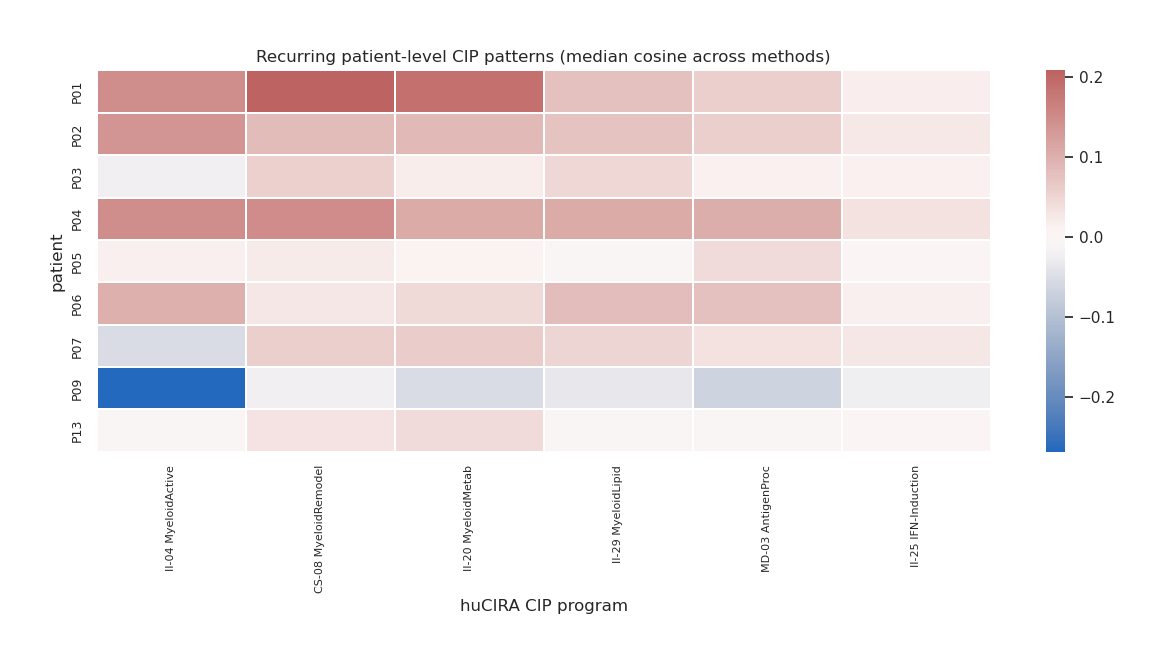

In [8]:
patient_program_summary_cip = (
    cip_long_scores.groupby(["patient", "program_name"], observed=False)
    .agg(
        n_models=("model_uid", "nunique"),
        mean_cosine=("cosine_similarity", "mean"),
        median_cosine=("cosine_similarity", "median"),
        max_abs_cosine=("cosine_similarity", lambda s: float(np.nanmax(np.abs(s)))),
        min_cosine=("cosine_similarity", "min"),
        max_cosine=("cosine_similarity", "max"),
        mean_pearson=("pearson_correlation", "mean"),
        mean_overlap_n=("overlap_n", "mean"),
        n_positive=("cosine_similarity", lambda s: int((s > 0).sum())),
        n_negative=("cosine_similarity", lambda s: int((s < 0).sum())),
    )
    .reset_index()
)
patient_program_summary_cip["sign_consistency"] = (
    (patient_program_summary_cip["n_positive"] - patient_program_summary_cip["n_negative"]).abs()
    / patient_program_summary_cip["n_models"].clip(lower=1)
)
patient_program_summary_cip["interpretation_flag"] = patient_program_summary_cip.apply(_interpretation_flag, axis=1)
patient_program_summary_cip = patient_program_summary_cip.sort_values(
    ["patient", "max_abs_cosine", "program_name"],
    ascending=[True, False, True],
)
display(Markdown("### Patient x CIP program summary"))
display(patient_program_summary_cip.head(30))
patient_program_summary_cip.to_csv(presentation_out / "patient_cip_program_summary.csv", index=False)

# pivot the patient_program_summary table to a patient x program heatmap
patient_program_heatmap = patient_program_summary_cip.pivot(index="patient", columns="program_name", values="median_cosine")
patient_top_programs = patient_program_heatmap.abs().max(axis=0).sort_values(ascending=False).head(20).index
fig, ax = plt.subplots(figsize=(max(12, 0.5 * len(patient_top_programs)), 6))
sns.heatmap(
    patient_program_heatmap.loc[:, patient_top_programs],
    cmap="vlag",
    center=0,
    linewidths=0.2,
    linecolor="white",
    ax=ax,
)
ax.set_title("Recurring patient-level CIP patterns (median cosine across methods)")
ax.set_xlabel("huCIRA CIP program")
ax.set_ylabel("patient")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelsize=9)
fig.tight_layout()
fig.savefig(presentation_out / "patient_by_cip_program_median_cosine_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

In [6]:
# Optional Hallmark GSEA per selected per-patient model
RUN_GSEA = True
GSEA_THREADS = int(os.environ.get("GSEA_THREADS", "4"))
GSEA_PERM = int(os.environ.get("GSEA_PERM", "200"))
GSEA_MIN_SIZE = int(os.environ.get("GSEA_MIN_SIZE", "15"))
GSEA_MAX_SIZE = int(os.environ.get("GSEA_MAX_SIZE", "500"))

try:
    import gseapy as gp
except Exception:
    gp = None
    if RUN_GSEA:
        raise RuntimeError("gseapy not installed. Install with: pip install gseapy")


def _safe_name(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x)).strip("_")


def _resolve_hallmark_gmt() -> Optional[Path]:
    env_path = os.environ.get("HALLMARK_GMT", "").strip()
    if env_path:
        p = Path(env_path)
        if p.exists():
            return p

    candidates = [
        Path("/home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.2.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v7.5.1.symbols.gmt"),
    ]
    for p in candidates:
        if p.exists():
            return p

    hits = sorted(Path(".").rglob("h.all*.gmt"))
    return hits[0] if hits else None


def _read_prerank_report_auto(report_csv: Path) -> pd.DataFrame:
    for sep in [",", "\t", None]:
        try:
            if sep is None:
                df = pd.read_csv(report_csv)
            else:
                df = pd.read_csv(report_csv, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(report_csv)


def run_or_read_prerank(series: pd.Series, gene_sets: Path, out_dir: Path) -> Optional[pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)
    canonical_cache = out_dir / "prerank_res2d_cached.csv"
    if canonical_cache.exists():
        return pd.read_csv(canonical_cache)

    report_candidates = [
        out_dir / "gseapy.gene_set.prerank.report.csv",
        out_dir / "gseapy.prerank.gene_sets.report.csv",
    ]
    for report_csv in report_candidates:
        if report_csv.exists():
            df = _read_prerank_report_auto(report_csv)
            df.to_csv(canonical_cache, index=False)
            return df

    if gp is None:
        return None

    rank_df = series.reset_index()
    rank_df.columns = ["gene", "score"]
    res = gp.prerank(
        rnk=rank_df,
        gene_sets=str(gene_sets),
        threads=GSEA_THREADS,
        permutation_num=GSEA_PERM,
        outdir=str(out_dir),
        seed=0,
        min_size=GSEA_MIN_SIZE,
        max_size=GSEA_MAX_SIZE,
        no_plot=True,
        format="png",
        verbose=False,
    )
    df = res.res2d.copy()
    df.to_csv(canonical_cache, index=False)
    return df


if RUN_GSEA:
    hallmark_gmt = _resolve_hallmark_gmt()
    if hallmark_gmt is None:
        raise FileNotFoundError("No Hallmark GMT found. Set HALLMARK_GMT env var or add h.all*.gmt")

    print("Using Hallmark GMT:", hallmark_gmt)
    gsea_root = OUTPUT_DIR / f"per_patient_hallmark_gsea__{SELECTION_MODE}"
    gsea_root.mkdir(parents=True, exist_ok=True)

    rows = []
    for model_uid in sig_df_pp.columns:
        patient, method, downsampling, penalty = model_uid.split("|", maxsplit=3)
        rank = sig_df_pp[model_uid].sort_values(ascending=False)
        out_dir = gsea_root / _safe_name(patient) / _safe_name(f"{method}|{downsampling}|{penalty}")
        df = run_or_read_prerank(rank, hallmark_gmt, out_dir)
        if df is None or df.empty:
            continue

        fdr_col = next((c for c in ["FDR q-val", "fdr", "fdr_q-val", "fdr_q_value"] if c in df.columns), None)
        nes_col = next((c for c in ["NES", "nes"] if c in df.columns), None)
        term_col = next((c for c in ["Term", "term", "NAME", "name"] if c in df.columns), None)
        fdr_num = pd.to_numeric(df[fdr_col], errors="coerce") if fdr_col is not None else pd.Series(np.nan, index=df.index)
        n_sig = int((fdr_num < 0.05).sum()) if fdr_col is not None else np.nan

        rows.append(
            {
                "patient": patient,
                "method": method,
                "downsampling": downsampling,
                "penalty": penalty,
                "model_uid": model_uid,
                "n_sig_pathways_fdr_lt_0p05": n_sig,
            }
        )

        if nes_col is not None and term_col is not None:
            nes_df = pd.DataFrame({"term": df[term_col], "NES": pd.to_numeric(df[nes_col], errors="coerce")}).dropna(subset=["NES"])
            top_pos = nes_df.nlargest(8, "NES")
            top_neg = nes_df.nsmallest(8, "NES")
            plot_df = pd.concat([top_neg, top_pos], ignore_index=True).sort_values("NES")
            if not plot_df.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                colors = np.where(plot_df["NES"] >= 0, "#b2182b", "#2166ac")
                ax.barh(plot_df["term"], plot_df["NES"], color=colors)
                ax.axvline(0, color="black", lw=1)
                ax.set_title(f"NES: {model_uid}")
                ax.set_xlabel("Normalized Enrichment Score (NES)")
                plt.tight_layout()
                fig.savefig(out_dir / "nes_top_pos_neg_barplot.png", dpi=160)
                plt.close(fig)

    gsea_counts = pd.DataFrame(rows).sort_values(["patient", "method", "downsampling", "penalty"])
    gsea_counts.to_csv(gsea_root / "hallmark_gsea_counts_per_selected_model.csv", index=False)
    display(gsea_counts)
    print("Saved GSEA outputs to:", gsea_root)
else:
    print("RUN_GSEA is False. Set RUN_GSEA=True to run Hallmark GSEA exports.")

Using Hallmark GMT: /home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt


,patient,method,downsampling,penalty,model_uid,n_sig_pathways_fdr_lt_0p05
0,P01,cnmf,none,elasticnet,P01|cnmf|none|elasticnet,6
1,P01,cnmf,none,l1,P01|cnmf|none|l1,0
2,P01,cnmf,none,l2,P01|cnmf|none|l2,11
3,P01,cnmf,random,elasticnet,P01|cnmf|random|elasticnet,7
4,P01,cnmf,random,l1,P01|cnmf|random|l1,0
...,...,...,...,...,...,...
265,P13,pca,none,l1,P13|pca|none|l1,29
266,P13,pca,none,l2,P13|pca|none|l2,12
267,P13,pca,random,elasticnet,P13|pca|random|elasticnet,14
268,P13,pca,random,l1,P13|pca|random|l1,29


Saved GSEA outputs to: /home/minhang/mds_project/sc_classification/scripts/comprehensive_run/notebooks/outputs/plan1d_k40_per_patient_full_reg_path_analysis_20260319/per_patient_hallmark_gsea__most_parsimonious_nonzero
